### Imports and File Configuration

In [21]:
# Cell 1: Imports and File Configuration

import copy
import json
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

np.random.seed(20260126)

# Root directory for the unzipped MTF 2022 survey data
DATA_ROOT = "RWA_2022_MTF_v01_M_CSV"
HH_DIR = os.path.join(DATA_ROOT, "household_survey_data")

# Fallback for flat directory structures
if not os.path.exists(HH_DIR):
    HH_DIR = "."

print(f">>> Environment Ready. Data Directory: {HH_DIR}")

>>> Environment Ready. Data Directory: RWA_2022_MTF_v01_M_CSV/household_survey_data


### Load Survey Data (MTF 2022)

In [22]:
# Cell 2: Load Survey Data (MTF 2022)

def safe_read(filename, cols=None):
    """Helper to read CSVs if they exist, returning None otherwise."""
    path = os.path.join(HH_DIR, filename)
    if os.path.exists(path):
        return pd.read_csv(path, usecols=cols)
    print(f"Warning: {filename} not found.")
    return None

print(">>> Loading Verified Survey Files...")

# 1. Roster: Weights & Location
# HI04: Urban/Rural (1=Urban, 2=Rural)
df_roster = safe_read("ROSTER_A1.csv", ["hhid", "Cluster", "PROVINCE", "DISTRICT", "HI04", "HH_WT", "ref_weight", "camp"])
if df_roster is None:
    raise FileNotFoundError("CRITICAL: ROSTER_A1.csv is required.")

# 2. Grid & Mini-Grid (SECTION_C1)
# Grid: C002, C029B (Day), C030B (Eve)
# Mini-Grid: C041, C070D (Day), C071D (Eve)
c1_cols = ["hhid", "C002", "C029B", "C030B", "C041", "C070D", "C071D"]
df_c1 = safe_read("SECTION_C1.csv", c1_cols)

# 3. Assets (SECTION_DE) aligned to MTF Tier proxies
asset_cols = [
    "hhid",

    # -------------------------
    # Tier 5 — Very High Power Appliances
    # (thermal conditioning & high-heat cooking loads)
    # -------------------------
    "E22A",  # Air conditioner
    "E24A",  # Electric water heater
    "E11A",  # Microwave oven

    # -------------------------
    # Tier 4 — High Power Appliances
    # (heavy household & productive loads)
    # -------------------------
    "E18A",  # Washing machine
    "E13A",  # Electric iron
    "E23A",  # Electric space heater
    "E34A",  # Electric mill
    "E35A",  # Electric water pump
    "E20A",  # Electric sewing machine
    "E14A",  # Hair dryer

    # -------------------------
    # Tier 3 — Medium Power Appliances
    # (cold chain & electric cooking/processing loads)
    # -------------------------
    "E10A",  # Refrigerator
    "E17A",  # Freezer
    "E16A",  # Rice cooker
    "E15A",  # Electric food processor / blender

    # -------------------------
    # Tier 2 — Low / Medium Plug Loads
    # (entertainment, comfort & connectivity devices)
    # -------------------------
    "E31A",  # Color TV
    "E32A",  # Flat color TV
    "E30A",  # Black & white TV
    "E26A",  # Computer
    "E09A",  # Fan
    "E06A",  # Radio
    "E07A",  # Radio / CD player / sound system
    "E08A",  # DVD / VCD player
    "E33A"   # Internet modem / router
]

df_de = safe_read("SECTION_DE.csv", asset_cols)

# 4. Financial Access (SECTION_B) - all cols to capture loan items
df_b_raw = safe_read("SECTION_B.csv")

# 5. Barriers (SECTION_MN)
# M02_01: "Appliance too expensive"
df_mn = safe_read("SECTION_MN.csv", ["hhid", "M02_01"])

# 6. Section H (H03-H06) plus weights (for credit lift and Accept_Cash)
df_h_raw = safe_read("SECTION_H.csv", ["hhid", "H03", "H04", "H05", "H06", "HH_WT"])

print(">>> Data Loading Complete.")


>>> Loading Verified Survey Files...
>>> Data Loading Complete.


### Cleaning and Merging

In [23]:
# DEFINE COLUMNS TO FORCE TO NUMERIC
numeric_cols = [
    'HH_WT', 'ref_weight', 'HI04',

    # Connection & availability (C1 section)
    'C002', 'C029B', 'C030B',
    'C041', 'C070D', 'C071D',

    # -------------------------
    # Appliance assets — Tier 5
    # -------------------------
    'E22A',  # Air conditioner
    'E24A',  # Electric water heater
    'E11A',  # Microwave oven

    # -------------------------
    # Appliance assets — Tier 4
    # -------------------------
    'E18A',  # Washing machine
    'E13A',  # Electric iron
    'E23A',  # Electric space heater
    'E34A',  # Electric mill
    'E35A',  # Electric water pump
    'E20A',  # Electric sewing machine
    'E14A',  # Hair dryer

    # -------------------------
    # Appliance assets — Tier 3
    # -------------------------
    'E10A',  # Refrigerator
    'E17A',  # Freezer
    'E16A',  # Rice cooker
    'E15A',  # Food processor / blender

    # -------------------------
    # Appliance assets — Tier 2
    # -------------------------
    'E31A',  # Color TV
    'E32A',  # Flat color TV
    'E30A',  # Black & white TV
    'E26A',  # Computer
    'E09A',  # Fan
    'E06A',  # Radio
    'E07A',  # Radio/CD system
    'E08A',  # DVD/VCD player
    'E33A',  # Internet modem/router

    # Financing / adoption (Section H)
    'H03', 'H04', 'H05', 'H06',

    # Barrier indicator (Section MN)
    'M02_01',

    # Geography (confirmed numeric codes)
    'Cluster', 'PROVINCE', 'DISTRICT'
]

# CONVERT & CLEAN NUMERIC COLUMNS
for df_temp in [df_roster, df_c1, df_de, df_mn, df_h_raw]:
    if df_temp is not None:
        for c in numeric_cols:
            if c in df_temp.columns:
                df_temp[c] = pd.to_numeric(df_temp[c], errors='coerce')

# Base DF from roster
df = df_roster.drop_duplicates(subset='hhid').copy()

# Weight fix: replace HH_WT with ref_weight when present & valid
if {'ref_weight', 'camp'}.issubset(df.columns):
    mask_ref = df['ref_weight'].gt(0) & df['camp'].notna()
    df.loc[mask_ref, 'HH_WT'] = df.loc[mask_ref, 'ref_weight']

# Fallback for weights
df['HH_WT'] = df['HH_WT'].fillna(df['HH_WT'].median())
df['HH_WT'] = pd.to_numeric(df['HH_WT'], errors='coerce').fillna(0.0)

# Merge modules
if df_c1 is not None: df = df.merge(df_c1, on='hhid', how='left')
if df_de is not None: df = df.merge(df_de, on='hhid', how='left')
if df_mn is not None: df = df.merge(df_mn, on='hhid', how='left')
# Merge Section H (H03–H06) so we can compute agent-level lift
if df_h_raw is not None:
    df = df.merge(df_h_raw[['hhid','H03','H04','H05','H06']], on='hhid', how='left')
    for c in ['H03','H04','H05','H06']:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)
else:
    for c in ['H03','H04','H05','H06']:
        df[c] = 0


# Financial Access (SECTION_B)
if df_b_raw is not None:
    df_b = df_b_raw.drop_duplicates(subset='hhid').copy()
    loan_cols = [c for c in df_b.columns if c.startswith('B08_')]
    if loan_cols:
        for c in loan_cols:
            df_b[c] = pd.to_numeric(df_b[c], errors='coerce').fillna(0)
        df_b['Any_Loan'] = (df_b[loan_cols] == 1).any(axis=1).astype(int)
    else:
        df_b['Any_Loan'] = 0
    b09 = pd.to_numeric(df_b.get('B09', 0), errors='coerce')
    df_b['Mobile_Money'] = (b09 == 1).astype(int)
    df_b['Has_Credit'] = (df_b['Any_Loan'] | df_b['Mobile_Money']).astype(int)
    df = df.merge(df_b[['hhid', 'Has_Credit']], on='hhid', how='left')
else:
    df['Has_Credit'] = 0

# Unified connection indicator (grid or mini-grid)
df['Conn_Grid'] = ((df.get('C002', 0) == 1) | (df.get('C041', 0) == 1)).astype(int)

# Reliability hours (grid default, override with mini-grid when available)
df['Hours'] = df.get('C029B', np.nan)
df['Evening_Hrs'] = df.get('C030B', np.nan)
mask_mini = (df.get('C041', 0) == 1)
if 'C070D' in df.columns:
    df.loc[mask_mini, 'Hours'] = df.loc[mask_mini, 'C070D'].where(df.loc[mask_mini, 'C070D'].notna(),
                                                                  df.loc[mask_mini, 'Hours'])
    df.loc[mask_mini, 'Evening_Hrs'] = df.loc[mask_mini, 'C071D'].where(df.loc[mask_mini, 'C071D'].notna(),
                                                                        df.loc[mask_mini, 'Evening_Hrs'])

# Zero out for unconnected
mask_conn = df['Conn_Grid'] == 1
df.loc[~mask_conn, ['Hours','Evening_Hrs']] = 0

# Bounds & simple hierarchical imputation
df['Hours'] = df['Hours'].where(df['Hours'].between(0,24))
df['Evening_Hrs'] = df['Evening_Hrs'].where(df['Evening_Hrs'].between(0,12))

for col in ['Cluster','PROVINCE']:
    if col not in df.columns:
        df[col] = 1

def wmean_hier(s):
    w = df.loc[s.index, 'HH_WT']
    
    # LEVEL 1: CLUSTER (Village)
    ok = s.notna() & w.gt(0)
    if ok.any(): return np.average(s[ok], weights=w[ok])
    
    # LEVEL 2: DISTRICT (District 11-57)
    dist = df.loc[s.index, 'DISTRICT'].iloc[0]
    cand_dist = df[df['DISTRICT'] == dist]
    ok_dist = cand_dist[s.name].notna() & cand_dist['HH_WT'].gt(0)
    if ok_dist.any(): return np.average(cand_dist[s.name][ok_dist], weights=cand_dist['HH_WT'][ok_dist])

    # LEVEL 3: PROVINCE (Province 1-5)
    prov = df.loc[s.index, 'PROVINCE'].iloc[0]
    cand_prov = df[df['PROVINCE'] == prov]
    ok_prov = cand_prov[s.name].notna() & cand_prov['HH_WT'].gt(0)
    if ok_prov.any(): return np.average(cand_prov[s.name][ok_prov], weights=cand_prov['HH_WT'][ok_prov])
    
    return 0

df.loc[mask_conn, 'Hours'] = df.loc[mask_conn].groupby('Cluster')['Hours'].transform(
    lambda s: s.fillna(wmean_hier(s))
).fillna(0)

df.loc[mask_conn, 'Evening_Hrs'] = df.loc[mask_conn].groupby('Cluster')['Evening_Hrs'].transform(
    lambda s: s.fillna(wmean_hier(s))
).fillna(0)

df['Hours'] = df['Hours'].clip(0,24)
df['Evening_Hrs'] = df['Evening_Hrs'].clip(0,12)

print(">>> Merge & basic cleaning complete.")
print(len(df), "households in final dataframe.")


>>> Merge & basic cleaning complete.
5706 households in final dataframe.


### Apply ABM Logic (Reliability & Tiers)
Converts raw survey answers into model parameters ($m(R)$, Tiers, Urban/Rural).

In [24]:
# Cell 4: ABM Parameters (m(R), Tier, Urban/Rural, Agent Table)

# Usability/availability score m(R)
daily_score = 0.15 + 0.85 * (df['Hours'] / 24.0) ** 0.8
evening_score = (df['Evening_Hrs'] / 4.0).clip(0, 1)
m_raw = 0.7 * daily_score + 0.3 * evening_score
df['m_R'] = np.where(df['Conn_Grid'] == 1, m_raw.clip(0, 1), 0.0)

# Urban flag (1=Urban, 0=Rural)
df['Is_Urban'] = (df.get('HI04', 2) == 1).astype(int)

# Tier mapping (winner-takes-all by highest load asset)

TIER5_VARS = ["E22A", "E24A", "E11A"]  # AC, water heater, microwave
TIER4_VARS = ["E18A", "E13A", "E23A", "E34A", "E35A", "E20A", "E14A"]
TIER3_VARS = ["E10A", "E17A", "E16A", "E15A"]
TIER2_VARS = ["E31A","E32A","E30A","E26A","E09A","E06A","E07A","E08A","E33A"]

def has_any_asset(row, cols):
    return any(row.get(c, 0) > 0 for c in cols)

def get_tier_strict(row):

    # -------- Tier 5 --------
    if has_any_asset(row, TIER5_VARS):
        return 5  # Very high load appliances

    # -------- Tier 4 --------
    elif has_any_asset(row, TIER4_VARS):
        return 4  # High load appliances

    # -------- Tier 3 --------
    elif has_any_asset(row, TIER3_VARS):
        return 3  # Medium load appliances

    # -------- Tier 2 --------
    elif has_any_asset(row, TIER2_VARS):
        return 2  # Low/medium plug loads

    # -------- Tier 1 --------
    elif row.get('Conn_Grid', 0) == 1:
        return 1  # Connected but no Tier 2+ assets

    # -------- Tier 0 --------
    else:
        return 0  # Not connected


df['Tier'] = df.apply(get_tier_strict, axis=1)

# Accept_Cash from Section H (fallback to 0 if missing)
for c in ['H03','H04','H05','H06']:
    if c not in df.columns:
        df[c] = 0
df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

# # Final agent table (consistent columns for solver)
# df_agents = df[['hhid','HH_WT','Conn_Grid','m_R','Tier','Accept_Cash']].copy()
# Ensure we use CapacityTier (if you only have 'Tier', map it once here)
if 'CapacityTier' not in df.columns and 'Tier' in df.columns:
    df['CapacityTier'] = df['Tier']

# --- FIX: ensure required columns exist before selecting cols_micro ---

# 1) Reliability alias
if 'UsabilityIndex' not in df.columns:
    if 'm_R' in df.columns:
        df['UsabilityIndex'] = df['m_R']
    else:
        print("Warning: 'm_R' not found; setting 'UsabilityIndex' to 0.0")
        df['UsabilityIndex'] = 0.0  # hard fallback (shouldn't happen)

# 2) Tier alias
if 'CapacityTier' not in df.columns:
    if 'Tier' in df.columns:
        df['CapacityTier'] = df['Tier'].astype(int)
    else:
        print("Warning: 'Tier' not found; setting 'CapacityTier' to 0")
        df['CapacityTier'] = 0

# 3) Section H guards (in case merge didn’t happen earlier)
for c in ['H03','H04','H05','H06']:
    if c not in df.columns:
        print(f"Warning: '{c}' not found; setting to 0")
        df[c] = 0

# (optional) sanity checks
assert {'UsabilityIndex','CapacityTier','HH_WT'}.issubset(df.columns), "Missing core inputs for df_agents"


cols_micro = [
    'hhid','HH_WT','Conn_Grid','UsabilityIndex','CapacityTier',
    'H03','H04','H05','H06'  # keep raw responses for agent-level lift
]
df_agents = df[cols_micro].copy()


print(f">>> ABM Parameters Calculated. Avg m(R) among connected: {np.average(df.loc[df['Conn_Grid']==1,'m_R'], weights=df.loc[df['Conn_Grid']==1,'HH_WT']):.2f}")
print(">>> Tier Distribution (Connected Only):")
print(df.loc[df['Conn_Grid']==1, 'Tier'].value_counts(normalize=True).sort_index())


>>> ABM Parameters Calculated. Avg m(R) among connected: 0.97
>>> Tier Distribution (Connected Only):
Tier
1    0.382187
2    0.296881
3    0.006013
4    0.290868
5    0.024051
Name: proportion, dtype: float64


### Validation Visualizations & Diagnostic Report (incl. Credit Lift)

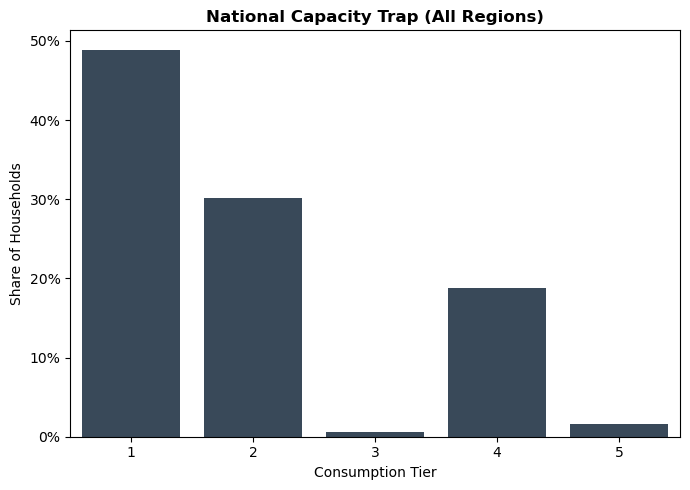

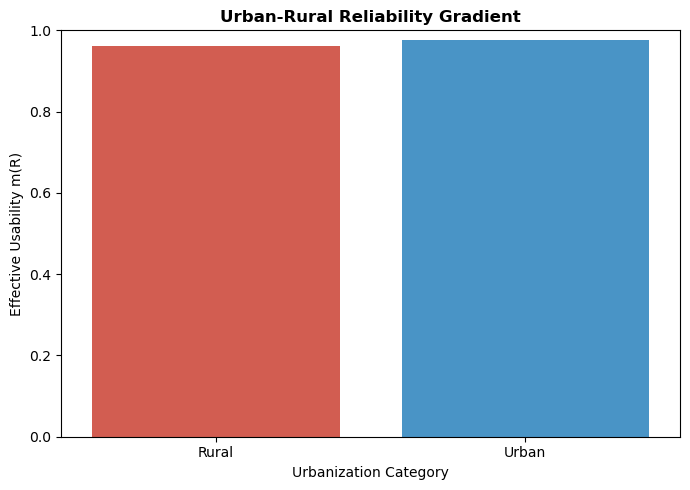

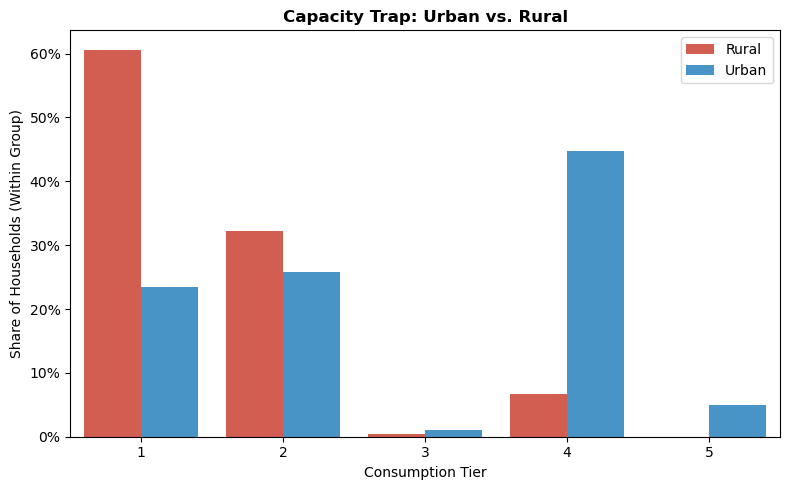

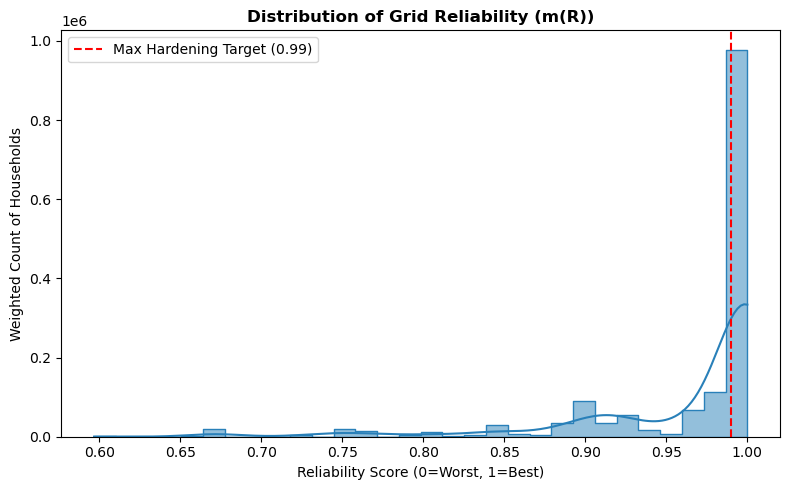

--- FINAL DIAGNOSTIC REPORT ---
1. RELIABILITY (m(R))
   - National Avg: 0.97
   - Urban:        0.98
   - Rural:        0.96
------------------------------
2. CAPACITY TRAP (Share of HHs in Tier 1)
   - National Avg: 48.9%
   - Urban:        23.5%
   - Rural:        60.6%


In [25]:
# Cell 5: Validation Visualizations & Diagnostic Report (CORRECTED)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import pandas as pd

# Prepare Data
grid_users = df[df['Conn_Grid']==1].copy()
grid_users['URB'] = np.where(grid_users['Is_Urban']==1, 'Urban', 'Rural')

# --- Plot 1: National Capacity Trap ---
plt.figure(figsize=(7,5))
nat_trap = grid_users.groupby('Tier')['HH_WT'].sum().reset_index()
nat_trap['Pct'] = nat_trap['HH_WT'] / nat_trap['HH_WT'].sum()
sns.barplot(data=nat_trap, x='Tier', y='Pct', order=[1,2,3,4,5], color="#34495e")
plt.title("National Capacity Trap (All Regions)", fontweight='bold')
plt.ylabel("Share of Households")
plt.xlabel("Consumption Tier")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig("fig_capacity_trap_national.png", dpi=300)
plt.show()

# --- Plot 2: Urban-Rural Reliability Gradient ---
# REFACTORED: Title and Filename updated to "Gradient" to match text
plt.figure(figsize=(7,5))
cliff_data = grid_users.groupby('URB')[['m_R','HH_WT']].apply(
    lambda x: np.average(x['m_R'], weights=x['HH_WT'])
).reset_index(name='m_R')
sns.barplot(data=cliff_data, x='URB', y='m_R', hue='URB', legend=False,
            order=['Rural','Urban'], palette=["#e74c3c","#3498db"])
plt.title("Urban-Rural Reliability Gradient", fontweight='bold')
plt.ylabel("Effective Usability m(R)")
plt.xlabel("Urbanization Category")
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("fig_reliability_gradient.png", dpi=300) 
plt.show()

# --- Plot 3: Capacity Trap by URB ---
plt.figure(figsize=(8,5))
trap_data = grid_users.groupby(['URB','Tier'])['HH_WT'].sum().reset_index()
totals = grid_users.groupby('URB')['HH_WT'].sum()
trap_data['Pct'] = trap_data.apply(lambda x: x['HH_WT'] / totals[x['URB']], axis=1)
sns.barplot(data=trap_data, x='Tier', y='Pct', hue='URB',
            hue_order=['Rural','Urban'], order=[1,2,3,4,5],
            palette=["#e74c3c","#3498db"])
plt.title("Capacity Trap: Urban vs. Rural", fontweight='bold')
plt.xlabel("Consumption Tier")
plt.ylabel("Share of Households (Within Group)")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.legend(title="")
plt.tight_layout()
plt.savefig("fig_capacity_trap_urban_rural.png", dpi=300)
plt.show()

# --- NEW PLOT: Reliability Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(data=grid_users, x='m_R', weights='HH_WT', 
             bins=30, kde=True, color="#2980b9", element="step")
plt.title("Distribution of Grid Reliability (m(R))", fontweight='bold')
plt.xlabel("Reliability Score (0=Worst, 1=Best)")
plt.ylabel("Weighted Count of Households")
plt.axvline(0.99, color='red', linestyle='--', label='Max Hardening Target (0.99)')
plt.legend()
plt.tight_layout()
plt.savefig("fig_reliability_distribution.png", dpi=300)
plt.show()

# --- Diagnostics (numbers) ---
def get_trap_share(subset_df):
    if subset_df.empty: return 0.0
    tier1_weight = subset_df[subset_df['Tier'] <= 1]['HH_WT'].sum()
    total_weight = subset_df['HH_WT'].sum()
    return tier1_weight / total_weight if total_weight > 0 else 0

national_trap = get_trap_share(grid_users)
national_mr = np.average(grid_users['m_R'], weights=grid_users['HH_WT'])
urban_subset = grid_users[grid_users['URB']=='Urban']
rural_subset = grid_users[grid_users['URB']=='Rural']
urban_trap = get_trap_share(urban_subset)
rural_trap = get_trap_share(rural_subset)
urban_mr_val = np.average(urban_subset['m_R'], weights=urban_subset['HH_WT'])
rural_mr_val = np.average(rural_subset['m_R'], weights=rural_subset['HH_WT'])

print("--- FINAL DIAGNOSTIC REPORT ---")
print("1. RELIABILITY (m(R))")
print(f"   - National Avg: {national_mr:.2f}")
print(f"   - Urban:        {urban_mr_val:.2f}")
print(f"   - Rural:        {rural_mr_val:.2f}")
print("-"*30)
print("2. CAPACITY TRAP (Share of HHs in Tier 1)")
print(f"   - National Avg: {national_trap:.1%}")
print(f"   - Urban:        {urban_trap:.1%}")
print(f"   - Rural:        {rural_trap:.1%}")


--- CREDIT LIFT CALCULATION ---
Cash Adoption: 30.9%
Total Adoption (w/ Credit): 49.2%
CREDIT MULTIPLIER: 1.59x
Absolute lift used in model: 0.183


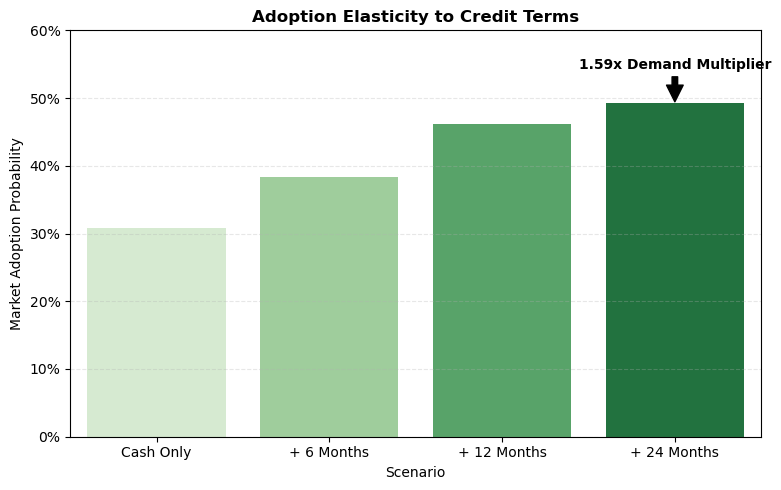

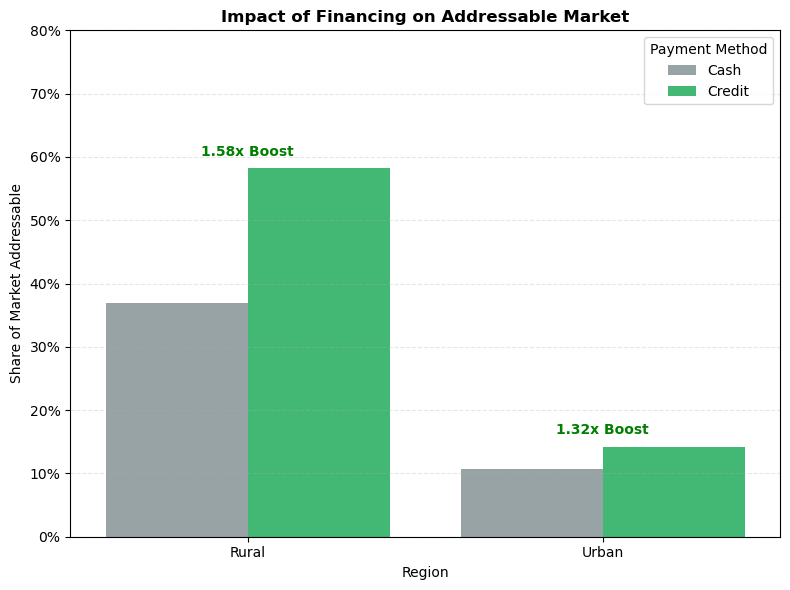

In [26]:
# Cell 5b: Credit Lift and Elasticity Analysis (Publication Ready)

print("\n--- CREDIT LIFT CALCULATION ---")
PROB_LIFT_FROM_DATA = 0.15  # default

if df_h_raw is not None:
    # 1) Build a clean Section-H table with its own weights
    h = (df_h_raw[['hhid','H03','H04','H05','H06','HH_WT']].copy()
           .rename(columns={'HH_WT':'H_WT'}))
    for c in ['H03','H04','H05','H06','H_WT']:
        h[c] = pd.to_numeric(h[c], errors='coerce')
    h[['H03','H04','H05','H06']] = h[['H03','H04','H05','H06']].fillna(0)
    h = h[h['H_WT'] > 0]

    # 2) Flags and national rates (weighted by H_WT)
    h['Accept_Cash']       = (h['H03'] == 1).astype(int)
    h['Accept_Credit_Any'] = ((h['H03']==1)|(h['H04']==1)|(h['H05']==1)|(h['H06']==1)).astype(int)

    rate_cash  = np.average(h['Accept_Cash'],       weights=h['H_WT'])
    rate_total = np.average(h['Accept_Credit_Any'], weights=h['H_WT'])
    multiplier = rate_total / rate_cash if rate_cash > 0 else np.nan
    abs_lift   = rate_total - rate_cash

    print(f"Cash Adoption: {rate_cash:.1%}")
    print(f"Total Adoption (w/ Credit): {rate_total:.1%}")
    print(f"CREDIT MULTIPLIER: {multiplier:.2f}x")
    print(f"Absolute lift used in model: {abs_lift:.3f}")

    # 3) Plot 1: The Credit Ladder (Cumulative Demand)
    rate_6m  = np.average(((h['H03']==1)|(h['H04']==1)).astype(int), weights=h['H_WT'])
    rate_12m = np.average(((h['H03']==1)|(h['H04']==1)|(h['H05']==1)).astype(int), weights=h['H_WT'])

    ladder = pd.DataFrame({
        'Scenario': ['Cash Only', '+ 6 Months', '+ 12 Months', '+ 24 Months'],
        'Adoption': [rate_cash, rate_6m, rate_12m, rate_total]
    })

    plt.figure(figsize=(8,5))
    sns.barplot(data=ladder, x='Scenario', y='Adoption', hue='Scenario', palette="Greens", legend=False)
    plt.title("Adoption Elasticity to Credit Terms", fontweight='bold')
    plt.ylabel("Market Adoption Probability")
    plt.ylim(0,0.6) # Set limit to 60% for clarity
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Annotate the boost
    plt.annotate(f"{multiplier:.2f}x Demand Multiplier",
                 xy=(3, rate_total), xytext=(3, rate_total+0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05), ha='center', fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig_credit_ladder.png", dpi=300)
    plt.show()

    # 4) Plot 2: Regional Sensitivity (Urban vs Rural)
    h_ur = h.merge(df_roster[['hhid','HI04']], on='hhid', how='left')
    h_ur['Region'] = np.where(h_ur['HI04'] == 1, 'Urban', 'Rural')

    def wavg(s, w): return np.average(s, weights=w) if np.isfinite(w).all() and w.sum() > 0 else np.nan

    rows = []
    for region, g in h_ur.groupby('Region'):
        w  = g['H_WT']
        rc = wavg(g['Accept_Cash'], w)
        rt = wavg(g['Accept_Credit_Any'], w)
        rows.append({'Region': region, 'Scenario': 'Cash',   'Adoption': rc})
        rows.append({'Region': region, 'Scenario': 'Credit', 'Adoption': rt})

    plot_data = pd.DataFrame(rows)

    plt.figure(figsize=(8,6))
    sns.barplot(data=plot_data, x='Region', y='Adoption', hue='Scenario',
                palette=["#95a5a6", "#2ecc71"])
    plt.title("Impact of Financing on Addressable Market", fontweight='bold')
    plt.ylabel("Share of Market Addressable")
    plt.ylim(0,0.8)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    for i, region in enumerate(['Rural', 'Urban']): # Check order depending on pandas sort
        # Ensure we get the right region data regardless of plot order
        if region not in plot_data['Region'].values: continue
        
        rc_val = plot_data.query("Region == @region and Scenario == 'Cash'")['Adoption'].values[0]
        rt_val = plot_data.query("Region == @region and Scenario == 'Credit'")['Adoption'].values[0]
        mult = (rt_val/rc_val) if rc_val > 0 else 0
        
        # Position calculations need to align with seaborn's bar placement
        # Rural is typically index 0, Urban index 1 (alphabetical reverse or as sorted)
        # We'll just hardcode annotation locations relative to the bars height
        plt.text(i, rt_val + 0.02, f"{mult:.2f}x Boost", 
                 color='green', fontweight='bold', ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title="Payment Method")
    plt.tight_layout()
    plt.savefig("fig_credit_regional.png", dpi=300)
    plt.show()

    PROB_LIFT_FROM_DATA = float(abs_lift)
else:
    print("Section H not available; skipping ladder/multiplier plots.")

### Export Survey Inputs (Agents, Sector Aggregates, ABM Inputs, Assumptions)

In [27]:
# Cell 6: Export Survey Inputs (Agents, Sector Aggregates, ABM Inputs, Assumptions)

# 1) Micro-Agents
cols_micro = ['hhid','Cluster','PROVINCE','HH_WT','Conn_Grid','m_R','Tier','Is_Urban','Accept_Cash']
df[cols_micro].to_csv("abm_agents.csv", index=False)

# 2) Sector Aggregates
def weighted_agg(x):
    w = x['HH_WT']
    if w.sum() == 0:
        return pd.Series({'Avg_Reliability':0, 'Grid_Access':0, 'Productive_Share':0, 'Pop_Weight':0, 'Is_Urban':x['Is_Urban'].max()})
    return pd.Series({
        'Avg_Reliability': np.average(x['m_R'], weights=w),
        'Grid_Access': np.average(x['Conn_Grid'], weights=w),
        'Productive_Share': np.average((x['Tier']>=2).astype(float), weights=w),
        'Pop_Weight': w.sum(),
        'Is_Urban': x['Is_Urban'].max()
    })

cols_agg = ['m_R','Conn_Grid','Tier','HH_WT','Is_Urban']
sector_agg = df.groupby('Cluster')[cols_agg].apply(weighted_agg).reset_index()
sector_agg.to_csv("sector_aggregates.csv", index=False)

# 3) ABM inputs (renamed)
abm_inputs = sector_agg.rename(columns={
    'Avg_Reliability':'m_R_avg',
    'Grid_Access':'access_rate',
    'Productive_Share':'share_tier_ge2',
    'Pop_Weight':'pop_weight'
})[['Cluster','m_R_avg','access_rate','share_tier_ge2','pop_weight','Is_Urban']]
abm_inputs.to_csv("abm_inputs.csv", index=False)

# 4) Metadata
assumptions = {
    'HI04': '1=Urban, 2=Rural',
    'Conn_Grid': 'Grid (C002) OR Mini-Grid (C041)',
    'Hours': 'C029B (Grid) or C070D (Mini)',
    'Credit_Lift': 'Data-driven absolute lift from Section H (Accept_Credit_Any - Accept_Cash)'
}
with open('mtf_assumptions.json', 'w') as f:
    json.dump(assumptions, f, indent=2)

print("Artifacts Generated: abm_agents.csv, sector_aggregates.csv, abm_inputs.csv, mtf_assumptions.json")


Artifacts Generated: abm_agents.csv, sector_aggregates.csv, abm_inputs.csv, mtf_assumptions.json


### Utility Baseline (TTM) from RURA and Save

In [28]:
# Cell 7: Utility Baseline (TTM) - Updated with Q2 2024 Report

# TTM Calculation: Q3 2023 + Q4 2023 + Q1 2024 + Q2 2024
# Source: Table 3 (Sales) and Table 1 (Generation) from Q2 2024 Report

# 1. Total Electricity Sold (kWh)
# Q3'23: 268,746,539 | Q4'23: 275,148,722 | Q1'24: 279,071,046 | Q2'24: 297,107,270
total_sales_kwh = 268746539 + 275148722 + 279071046 + 297107270
total_sales_gwh = total_sales_kwh / 1e6

# 2. Residential Sales (kWh)
# Q3'23: 55,420,152 | Q4'23: 56,716,702 | Q1'24: 58,677,996 | Q2'24: 61,233,673
res_sales_kwh = 55420152 + 56716702 + 58677996 + 61233673
res_sales_gwh = res_sales_kwh / 1e6

# 3. Total Generation (kWh)
# Q3'23: 325,175,399 | Q4'23: 333,210,202 | Q1'24: 342,072,816 | Q2'24: 365,934,860
total_gen_kwh = 325175399 + 333210202 + 342072816 + 365934860

# 4. Network Losses (Technical + Commercial)
# Derived: (Gen - Sold) / Gen
loss_rate = (total_gen_kwh - total_sales_kwh) / total_gen_kwh

utility_baseline = {
    "Total_Customers": 1_360_000,   # Reg. estimate (approx stable)
    "Annual_Gen_GWh": total_gen_kwh / 1e6,
    "Annual_Sold_GWh": total_sales_gwh,
    "Residential_Sold_GWh": res_sales_gwh,
    "Residential_Share": res_sales_kwh / total_sales_kwh,
    "Technical_Losses": loss_rate,
    "Peak_Demand_MW": 233.74,       # UPDATED: New Peak from Q2 2024 
    "Cost_Recovery_Target_Frw": 360 # Tariff structure remains unchanged 
}

pd.DataFrame([utility_baseline]).to_csv("utility_baseline_2024.csv", index=False)

print(f">>> Baseline Updated (TTM Q2 2024).")
print(f"    - Peak Demand: {utility_baseline['Peak_Demand_MW']} MW")
print(f"    - System Losses: {loss_rate:.1%}")
print(f"    - Residential Sales: {res_sales_gwh:.1f} GWh/yr")

>>> Baseline Updated (TTM Q2 2024).
    - Peak Demand: 233.74 MW
    - System Losses: 18.0%
    - Residential Sales: 232.0 GWh/yr


### Stackelberg Game Configuration & Simulation

>>> Solving with STRICT SUPPLY-CONSTRAINED Logic...


/var/folders/h4/2wxvtgv151xg0k3b7dbz8ljh0000gn/T/ipykernel_95807/1339979764.py:119: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wmean(g['A_win'], g['HH_WT']))


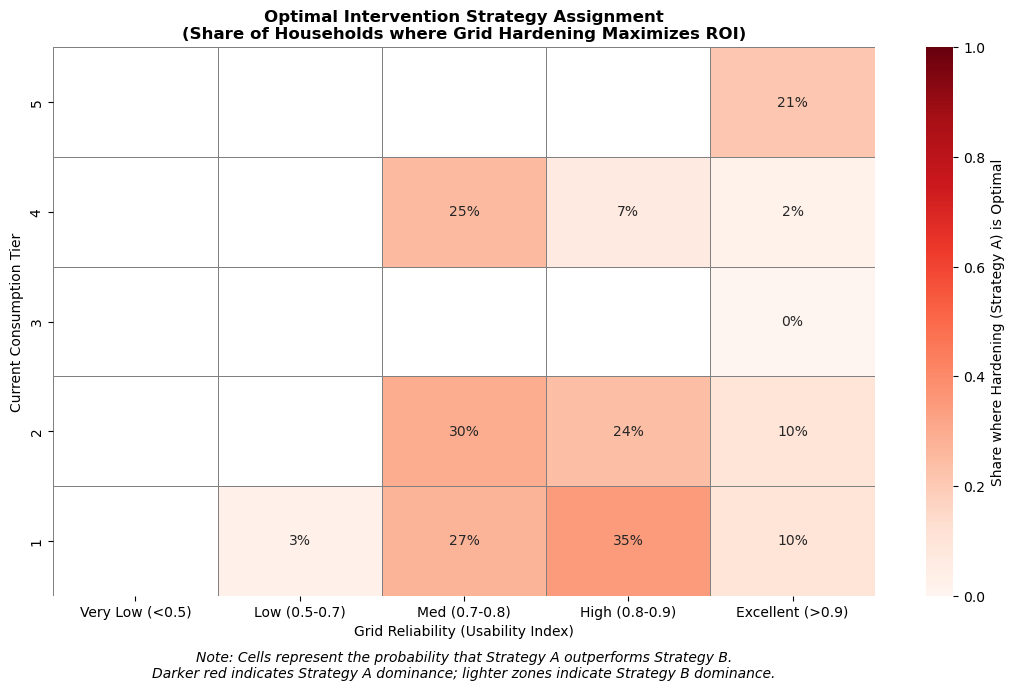


--- FINAL RESULTS (Connected HHs Only) ---
Financing (B) dominates in: 74.2% of households
Hardening (A) dominates in: 10.5% of households
No Viable Intervention:     15.3% of households


In [29]:
# Cell 8: Stackelberg Game Configuration & Simulation 
# --- Configuration ---
CONFIG_FAIR = {
    "P_BASE": 0.02,
    "COST_GRID_PER_HH": 100_000,
    "COST_CAPITAL_SUBSIDY": 300_000,
    "DEFAULT_RATE": 0.08,
    "ADMIN_PER_LOAN": 5_000,
    "TARIFF_BLOCKS": [
        {"limit": 15, "price": 89},
        {"limit": 50, "price": 310},
        {"limit": 9_999, "price": 369}
    ],
    "TIER_KWH_MONTHLY": {0:0, 1:5, 2:15, 3:30, 4:150, 5:250}
}

ABSOLUTE_LIFT = float(PROB_LIFT_FROM_DATA) if 'PROB_LIFT_FROM_DATA' in globals() else 0.183

# --- Billing Functions ---
def block_bill(kwh, blocks):
    bill, rem, prev = 0.0, kwh, 0
    for b in sorted(blocks, key=lambda z: z['limit']):
        span = b['limit'] - prev
        take = min(rem, span)
        bill += take * b['price']
        rem  -= take
        prev  = b['limit']
        if rem <= 0: break
    return bill

def annual_bill_from_kwh(monthly_kwh, config):
    return block_bill(monthly_kwh, config['TARIFF_BLOCKS']) * 12

def calculate_stackelberg_winner(agent_df, config, absolute_lift=0.15):
    df = agent_df.copy()

    # [Standard Aliases & Cleanup]
    if 'Tier' not in df.columns:
        df['Tier'] = df['CapacityTier'].astype(int) if 'CapacityTier' in df.columns else 0
    if 'm_R' not in df.columns:
        df['m_R'] = df['UsabilityIndex'].astype(float) if 'UsabilityIndex' in df.columns else 0.0
    for c in ['H03', 'H04', 'H05', 'H06']: 
        if c not in df.columns: df[c] = 0
    df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

    # --- 1. BASELINE ---
    base_kwh_monthly = df['Tier'].map(config['TIER_KWH_MONTHLY']).fillna(0)
    u0 = df['m_R'].replace(0, 0.01)
    
    # --- 2. STRATEGY A: HARDENING ---
    u1 = np.minimum(u0 * 1.2, 0.99)
    base_rev    = (base_kwh_monthly * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    strat_A_rev = (base_kwh_monthly * u1).apply(lambda k: annual_bill_from_kwh(k, config))
    
    rev_gain_A = strat_A_rev - base_rev
    cost_A     = config['COST_GRID_PER_HH']
    df['ROI_A'] = np.where(df['Conn_Grid'] == 1, rev_gain_A / cost_A, 0.0)

    # --- 3. STRATEGY B: FINANCING ---
    next_kwh_monthly = (df['Tier'] + 1).clip(0, 5).map(config['TIER_KWH_MONTHLY'])
    next_rev = (next_kwh_monthly * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    
    risk_cost   = config['COST_CAPITAL_SUBSIDY'] * config['DEFAULT_RATE']
    unit_cost_B = max(risk_cost + config['ADMIN_PER_LOAN'], 1e-9)
    
    rev_gain_B = (next_rev - base_rev) * absolute_lift * np.power(u0, 0.6)
    
    # Eligibility: Not Tier 5, and must not have accepted cash (unless willing to credit)
    elig_B = (df['Tier'] < 5) & ((df['Accept_Cash'] == 0) | (df['H04'] == 1) | (df['H05'] == 1) | (df['H06'] == 1))
    rev_gain_B[~elig_B] = 0.0
    
    df['ROI_B'] = np.where(df['Conn_Grid'] == 1, rev_gain_B / unit_cost_B, 0.0)

    # --- 4. STRICT WINNER LOGIC ---
    EPS = 1e-9
    df['Winner'] = 'None'
    
    # Hardening wins if ROI_A > ROI_B and ROI_A > 0
    mask_A = (df['ROI_A'] > df['ROI_B'] + EPS) & (df['ROI_A'] > EPS)
    df.loc[mask_A, 'Winner'] = 'Hardening'
    
    # Financing wins if ROI_B > ROI_A and ROI_B > 0
    mask_B = (df['ROI_B'] > df['ROI_A'] + EPS) & (df['ROI_B'] > EPS)
    df.loc[mask_B, 'Winner'] = 'Financing'
    
    return df

# ... [Previous Configuration and Calculation Logic remains the same] ...

print(">>> Solving with STRICT SUPPLY-CONSTRAINED Logic...")
df_solved = calculate_stackelberg_winner(df_agents, CONFIG_FAIR, ABSOLUTE_LIFT)

# --- VISUALIZATION: ROBUST MASKED HEATMAP ---

# 1. Define Ordered Categories
rel_cats = ['Very Low (<0.5)', 'Low (0.5-0.7)', 'Med (0.7-0.8)', 'High (0.8-0.9)', 'Excellent (>0.9)']
rel_dtype = pd.CategoricalDtype(categories=rel_cats, ordered=True)

df_solved['Rel_Bin'] = pd.cut(
    df_solved['m_R'],
    bins=[0, 0.5, 0.7, 0.8, 0.9, 1.0],
    labels=rel_cats,
    include_lowest=True
).astype(rel_dtype)

# 2. Filter for Connected Only
conn = df_solved[df_solved['Conn_Grid'] == 1].copy()

# 3. Helper for Weighted Mean
def wmean(x, w):
    return np.average(x, weights=w) if np.sum(w) > 0 else np.nan

# 4. Prepare Flags
conn['A_win'] = (conn['Winner'] == 'Hardening').astype(float)
conn['B_win'] = (conn['Winner'] == 'Financing').astype(float)

# 5. Create Pivots
pivot_A = (conn.groupby(['Tier', 'Rel_Bin'], observed=False)
              .apply(lambda g: wmean(g['A_win'], g['HH_WT']))
              .unstack())

# Reindex Tiers (5 at top, 1 at bottom)
tier_order = [5, 4, 3, 2, 1]
pivot_A = pivot_A.reindex(index=tier_order, columns=rel_cats).fillna(0.0)

# 6. SUPPORT MASKING (Hide cells with < 0.5% of population)
support_w = (conn.groupby(['Tier', 'Rel_Bin'], observed=False)['HH_WT']
                .sum().unstack().reindex(index=tier_order, columns=rel_cats).fillna(0.0))

support_pct_all = support_w / support_w.values.sum() * 100.0
LOW_SUPPORT_THRESHOLD = 0.5 
mask_low = support_pct_all < LOW_SUPPORT_THRESHOLD

# Create Annotation Strings
annot = (pivot_A * 100).round().astype(int).astype(str) + '%'
annot = annot.where(~mask_low, other='')

# 7. Plotting
plt.figure(figsize=(11, 7))
sns.heatmap(
    pivot_A, 
    annot=annot, 
    fmt='', 
    cmap="Reds", 
    mask=mask_low,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Share where Hardening (Strategy A) is Optimal'},
    linewidths=0.5, linecolor='gray'
)

plt.title("Optimal Intervention Strategy Assignment\n(Share of Households where Grid Hardening Maximizes ROI)", fontsize=12, fontweight='bold')
plt.ylabel("Current Consumption Tier")
plt.xlabel("Grid Reliability (Usability Index)")

# Add Explanatory Note
plt.text(0.5, -0.15, "Note: Cells represent the probability that Strategy A outperforms Strategy B.\nDarker red indicates Strategy A dominance; lighter zones indicate Strategy B dominance.",
         transform=plt.gca().transAxes, ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig("fig_policy_dominance.png", dpi=300)
plt.show()

# --- VALIDATION REPORT ---
w = conn['HH_WT']
share_B = np.average(conn['B_win'], weights=w)
share_A = np.average(conn['A_win'], weights=w)
share_None = 1.0 - (share_A + share_B)

print(f"\n--- FINAL RESULTS (Connected HHs Only) ---")
print(f"Financing (B) dominates in: {share_B:.1%} of households")
print(f"Hardening (A) dominates in: {share_A:.1%} of households")
print(f"No Viable Intervention:     {share_None:.1%} of households")

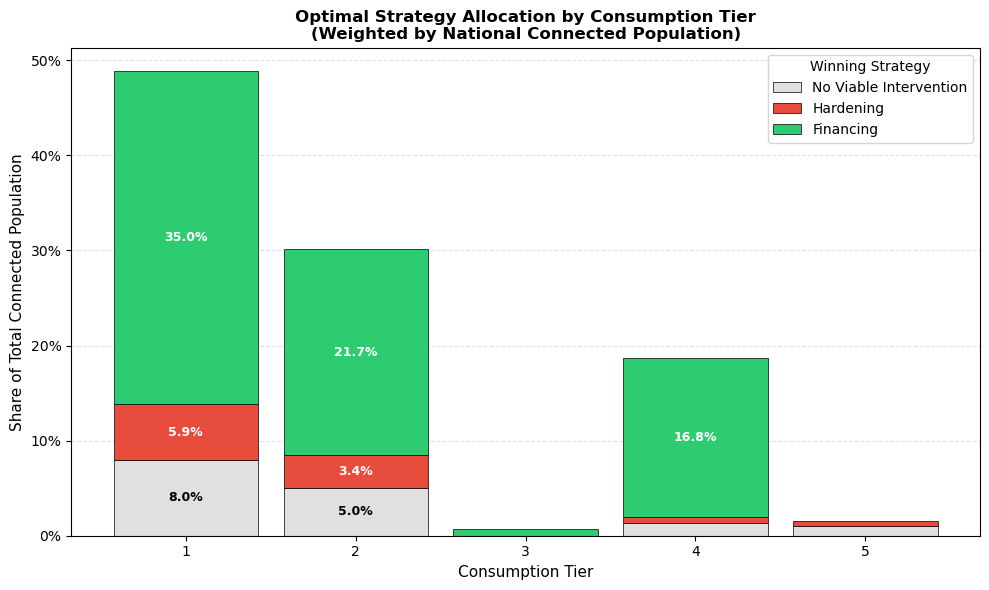


Column totals (Strategy Shares):
Winner
None         15.32%
Hardening    10.46%
Financing    74.22%
dtype: object

Tier totals (Demographic Shares):
Tier
1    48.88%
2    30.16%
3     0.66%
4    18.74%
5     1.56%
dtype: object


In [30]:
# Cell 13: Population-Weighted Dominance Analysis (Publication Ready)

import matplotlib.ticker as mtick
import numpy as np # Ensure numpy is imported for isclose

# 1. Prepare Data: Group by Tier and Winner, sum the Weights
tiers = [1, 2, 3, 4, 5]
pop_view = (
    df_solved[df_solved['Conn_Grid'] == 1]
      .groupby(['Tier', 'Winner'], observed=False)['HH_WT']
      .sum()
      .unstack(fill_value=0)
      .reindex(index=tiers, fill_value=0)
)

# 2. Convert to "Share of Total Population"
total_pop_weight = pop_view.values.sum()
pop_share = pop_view / total_pop_weight

# 3. Plot Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Financing': '#2ecc71', 
    'Hardening': '#e74c3c', 
    'None': '#e0e0e0'  # Light Gray
}

# Order: None -> Hardening -> Financing
plot_cols = ['None', 'Hardening', 'Financing']
pop_share = pop_share.reindex(columns=plot_cols, fill_value=0)

pop_share.plot(
    kind='bar', 
    stacked=True, 
    color=[colors[c] for c in plot_cols], 
    ax=ax, 
    width=0.85,
    edgecolor='black',
    linewidth=0.5
)

# 4. Formatting
ax.set_title("Optimal Strategy Allocation by Consumption Tier\n(Weighted by National Connected Population)", fontsize=12, fontweight='bold')
ax.set_ylabel("Share of Total Connected Population", fontsize=11)
ax.set_xlabel("Consumption Tier", fontsize=11)

# Format Y-axis as Percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_axisbelow(True); ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Legend
handles, labels = ax.get_legend_handles_labels()
labels = [l if l != 'None' else 'No Viable Intervention' for l in labels]
ax.legend(handles, labels, title="Winning Strategy", loc='upper right', frameon=True)

# 5. Robust Bar Labels
for container in ax.containers:
    vals = [p.get_height() for p in container]
    fc = container.patches[0].get_facecolor()
    luminance = 0.299*fc[0] + 0.587*fc[1] + 0.114*fc[2]
    text_color = 'black' if luminance > 0.6 else 'white'
    
    # Only label segments > 2%
    labels_pct = [f"{v:.1%}" if v > 0.02 else "" for v in vals]
    ax.bar_label(container, labels=labels_pct, label_type='center', 
                 color=text_color, fontsize=9, weight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fig_strategy_distribution.png", dpi=300)
plt.show()

# 6. Exact Breakdown & Sanity Checks
col_totals = pop_share.sum(axis=0)
row_totals = pop_share.sum(axis=1)

# Assertions
assert np.isclose(col_totals.sum(), 1.0), "Winner columns must sum to 100%."
assert np.isclose(row_totals.sum(), 1.0), "Tier shares must sum to 100%."

print("\nColumn totals (Strategy Shares):")
print(col_totals.map(lambda x: f"{x:.2%}"))
print("\nTier totals (Demographic Shares):")
print(row_totals.map(lambda x: f"{x:.2%}"))

In [31]:
# Updated Leader Allocation Function (Mutually Exclusive Greedy)

def solve_allocation_by_marginal(agent_df, config, budget, absolute_lift=None):
    if absolute_lift is None and 'ABSOLUTE_LIFT' in globals():
        absolute_lift = ABSOLUTE_LIFT

    # 1. Calculate ROIs for everyone
    st = calculate_stackelberg_winner(agent_df, config, absolute_lift=absolute_lift)

    cost_A = max(config['COST_GRID_PER_HH'], 1e-9)
    # Ensure Cost B uses the Risk-Adjusted logic
    cost_B = max(config['ADMIN_PER_LOAN'] + config['DEFAULT_RATE']*config['COST_CAPITAL_SUBSIDY'], 1e-9)

    roiA = st['ROI_A'].values
    roiB = st['ROI_B'].values
    
    # 2. DECISION: Pick the better strategy per household
    choose_B = roiB > roiA

    # 3. Create the "Density" list (Gain per Cost)
    dens   = np.where(choose_B, roiB, roiA)
    costs  = np.where(choose_B, cost_B, cost_A)
    labels = np.where(choose_B, 1, 0) # 0=A, 1=B
    mass   = st['HH_WT'].values

    # 4. Filter: Ignore non-positive investments
    keep = dens > 0
    dens, costs, labels, mass = dens[keep], costs[keep], labels[keep], mass[keep]

    # 5. Sort by Density (Best Bang-for-Buck first)
    order = np.argsort(-dens)
    
    spend_A = spend_B = profit = 0.0
    rem = float(budget)

    for j in order:
        if rem <= 0: break
        c, w = float(costs[j]), float(mass[j])
        
        # How many households can we treat?
        take = min(w, rem / c)
        if take <= 0: continue
        
        profit += dens[j] * c * take    # Gain
        
        if labels[j] == 0: 
            spend_A += c * take
        else:              
            spend_B += c * take
            
        rem -= c * take

    return spend_A, spend_B, profit

=== One-shot Stackelberg Allocation (Leader) ===
Budget:          20,000,000,000 RWF
Spend on A:      1,633,890,560 RWF  (8.2%)
Spend on B:      18,366,109,440 RWF  (91.8%)
Expected profit: 25,389,244,376 RWF


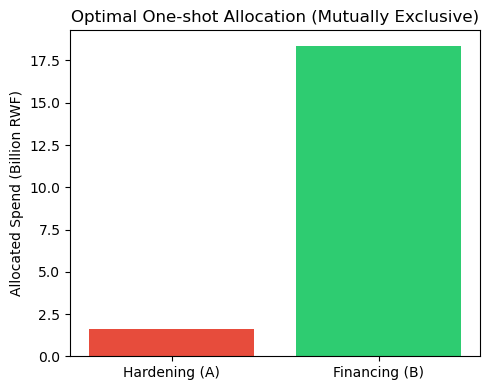

In [32]:
# Run the allocation
BUDGET_ONE_SHOT = CONFIG_FAIR.get('ANNUAL_BUDGET_RWF', 20_000_000_000)

spend_A, spend_B, profit = solve_allocation_by_marginal(
    df_agents, CONFIG_FAIR, BUDGET_ONE_SHOT, absolute_lift=ABSOLUTE_LIFT
)

total = spend_A + spend_B
print("=== One-shot Stackelberg Allocation (Leader) ===")
print(f"Budget:          {BUDGET_ONE_SHOT:,.0f} RWF")
print(f"Spend on A:      {spend_A:,.0f} RWF  ({spend_A/max(total,1e-9):.1%})")
print(f"Spend on B:      {spend_B:,.0f} RWF  ({spend_B/max(total,1e-9):.1%})")
print(f"Expected profit: {profit:,.0f} RWF")

# Quick bar plot
plt.figure(figsize=(5,4))
plt.bar(['Hardening (A)','Financing (B)'], [spend_A/1e9, spend_B/1e9], color=['#e74c3c', '#2ecc71'])
plt.ylabel('Allocated Spend (Billion RWF)')
plt.title('Optimal One-shot Allocation (Mutually Exclusive)')
plt.tight_layout()
plt.show()

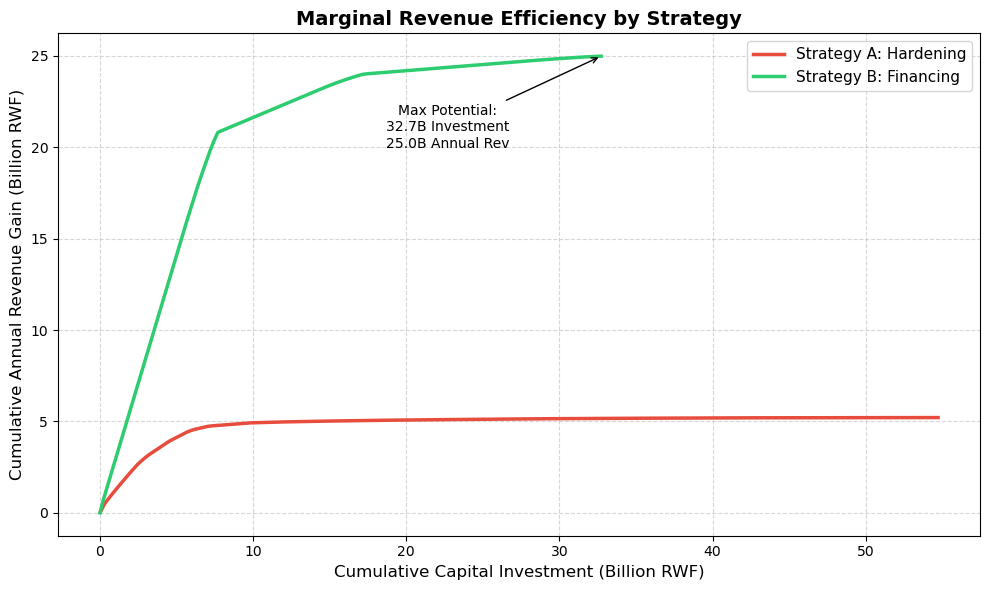

--- STRATEGY B POTENTIAL ---
Total Investable Capital: 32.72 Billion RWF
Total Annual Revenue:     24.97 Billion RWF
Average Payback Period:   1.31 Years


In [33]:
# Cell 12: Cumulative Revenue vs Cost (Marginal Efficiency Frontier)

# --- Helper ---
def calculate_annual_bill(monthly_kwh, config):
    return block_bill(monthly_kwh, config['TARIFF_BLOCKS']) * 12

# --- Re-calculate Metrics based on df_solved ---
base_kwh = df_solved['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
next_kwh = (df_solved['Tier'] + 1).clip(0, 5).map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)

u0 = df_solved['m_R'].replace(0, 0.01)
u1 = np.minimum(u0 * 1.2, 0.99)

# Baseline & Potential Revenue
base_rev = (base_kwh * u0).apply(lambda k: calculate_annual_bill(k, CONFIG_FAIR))
next_rev = (next_kwh * u0).apply(lambda k: calculate_annual_bill(k, CONFIG_FAIR))
strat_A_rev = (base_kwh * u1).apply(lambda k: calculate_annual_bill(k, CONFIG_FAIR))

# --- Strategy A: Hardening Analysis ---
gain_A = strat_A_rev - base_rev
cost_A = CONFIG_FAIR['COST_GRID_PER_HH']
roi_A  = np.where(df_solved['Conn_Grid']==1, gain_A / cost_A, 0.0)

# Filter for strictly positive ROI (Rational Investor)
A_df = pd.DataFrame({
    'roi': roi_A,
    'gain': gain_A * df_solved['HH_WT'],
    'cost': cost_A * df_solved['HH_WT'],
    'ok': (df_solved['Conn_Grid']==1)
}).query("ok")
A_df = A_df[A_df['roi'] > 1e-9].sort_values('roi', ascending=False)

A_df['cum_cost'] = A_df['cost'].cumsum()
A_df['cum_gain'] = A_df['gain'].cumsum()

# --- Strategy B: Financing Analysis ---
risk_cost = CONFIG_FAIR['COST_CAPITAL_SUBSIDY'] * CONFIG_FAIR['DEFAULT_RATE']
unit_cost_B = risk_cost + CONFIG_FAIR['ADMIN_PER_LOAN']

gain_B = (next_rev - base_rev) * ABSOLUTE_LIFT * np.power(u0, 0.6)

# Eligibility Filter
elig_B = (df_solved['Tier'] < 5) & (
    (df_solved['Accept_Cash'] == 0) | (df_solved['H04'] == 1) | 
    (df_solved['H05'] == 1) | (df_solved['H06'] == 1)
)

roi_B = np.where((df_solved['Conn_Grid']==1) & elig_B, gain_B / unit_cost_B, 0.0)

# Filter for strictly positive ROI
B_df = pd.DataFrame({
    'roi': roi_B,
    'gain': (gain_B * df_solved['HH_WT']).where(elig_B & (df_solved['Conn_Grid']==1), 0.0),
    'cost': (unit_cost_B * df_solved['HH_WT']).where(elig_B & (df_solved['Conn_Grid']==1), 0.0),
})
B_df = B_df[B_df['roi'] > 1e-9].sort_values('roi', ascending=False)

B_df['cum_cost'] = B_df['cost'].cumsum()
B_df['cum_gain'] = B_df['gain'].cumsum()

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot Curves
plt.plot(A_df['cum_cost']/1e9, A_df['cum_gain']/1e9, label='Strategy A: Hardening', linewidth=2.5, color='#e74c3c')
plt.plot(B_df['cum_cost']/1e9, B_df['cum_gain']/1e9, label='Strategy B: Financing', linewidth=2.5, color='#2ecc71')

# Labels and Formatting
plt.xlabel("Cumulative Capital Investment (Billion RWF)", fontsize=12)
plt.ylabel("Cumulative Annual Revenue Gain (Billion RWF)", fontsize=12)
plt.title("Marginal Revenue Efficiency by Strategy", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Annotate Max Potential for Strategy B
if not B_df.empty:
    max_rev = B_df['cum_gain'].max()/1e9
    max_inv = B_df['cum_cost'].max()/1e9
    plt.annotate(f'Max Potential:\n{max_inv:.1f}B Investment\n{max_rev:.1f}B Annual Rev', 
                 xy=(max_inv, max_rev), 
                 xytext=(max_inv - 10, max_rev - 5), 
                 arrowprops=dict(facecolor='black', arrowstyle="->"),
                 fontsize=10, ha='center')

plt.tight_layout()
plt.savefig("fig_marginal_revenue_curves.png", dpi=300)
plt.show()

# --- Output Statistics ---
print(f"--- STRATEGY B POTENTIAL ---")
print(f"Total Investable Capital: {B_df['cum_cost'].max()/1e9:.2f} Billion RWF")
print(f"Total Annual Revenue:     {B_df['cum_gain'].max()/1e9:.2f} Billion RWF")
print(f"Average Payback Period:   {(B_df['cum_cost'].max()/B_df['cum_gain'].max()):.2f} Years")

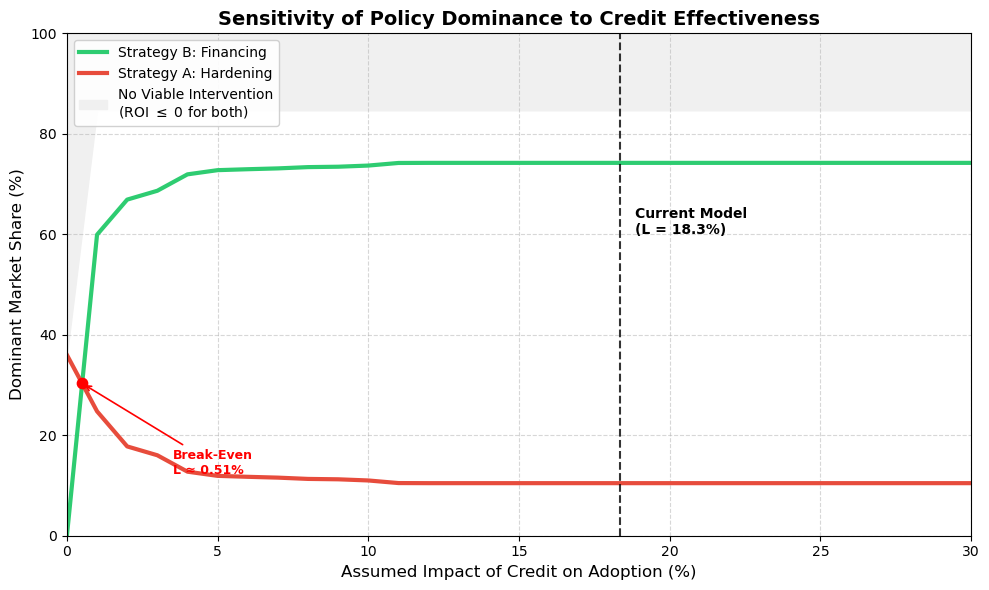

--- ROBUSTNESS REPORT (Connected HHs Only) ---
Consistency Check at L=0.0%:
  - Strategy B Share: 0.0% (Should be 0.0%)
  - Strategy A Share: 36.0% (Households needing reliability)
  - No Intervention:  64.0%

Break-even (intersection): L ≈ 0.51% at share ≈ 30.31% of connected HHs.
Saturation: Strategy B plateaus at ~74.2%.
  -> Why not 100%? Remaining 15.3% likely have ROI≤0 even with high credit lift.


In [34]:
# Cell 13: Sensitivity Analysis – Break-Even & Safety Margin
import matplotlib.ticker as mtick

def solve_with_lift_strict(L):
    # 1. Run the game with hypothetical Lift 'L'
    tmp = calculate_stackelberg_winner(df_agents, CONFIG_FAIR, absolute_lift=L)
    
    # FILTER: Align with Methodology (Post-connection analysis only)
    universe = tmp[tmp['Conn_Grid'] == 1].copy()
    w = universe['HH_WT']
    if w.sum() == 0:
        return 0.0, 0.0
    
    roi_A = universe['ROI_A']
    roi_B = universe['ROI_B']
    
    # EPSILON for numerical stability
    EPS = 1e-9
    
    # 2. STRICT DOMINANCE LOGIC
    mask_B_wins = (roi_B > roi_A + EPS) & (roi_B > EPS)
    mask_A_wins = (roi_A > roi_B + EPS) & (roi_A > EPS)
    
    # Weighted shares within the CONNECTED population
    share_B = np.average(mask_B_wins.astype(float), weights=w)
    share_A = np.average(mask_A_wins.astype(float), weights=w)
    return share_A, share_B

# 1. Run the Sensitivity Sweep
lifts = np.linspace(0.00, 0.30, 31)  # includes 0.0 exactly
res = np.array([solve_with_lift_strict(L) for L in lifts])

# 2. Break-even (true intersection via linear interpolation)
EPS = 1e-12
delta = res[:, 1] - res[:, 0]  # shares in [0,1]

# Find intersection
brackets = np.where((delta[:-1] < 0) & (delta[1:] > 0))[0]
if len(brackets) == 0:
    i_star = int(np.argmin(np.abs(delta)))
    L_star = lifts[i_star]
    share_star = res[i_star, 1]
else:
    i0 = int(brackets[0])
    d0, d1 = delta[i0], delta[i0 + 1]
    t = d0 / (d0 - d1)
    L_star = lifts[i0] + t * (lifts[i0 + 1] - lifts[i0])
    share_star = res[i0, 1] + t * (res[i0 + 1, 1] - res[i0, 1])

break_even_lift = L_star
break_even_share = share_star

# 3. Plot
plt.figure(figsize=(10, 6))

# Define Data Series
x = lifts * 100
y_A = res[:, 0] * 100
y_B = res[:, 1] * 100
y_None = 100 - (y_A + y_B)

# Curves
plt.plot(x, y_B, label='Strategy B: Financing', color='#2ecc71', linewidth=3)
plt.plot(x, y_A, label='Strategy A: Hardening', color='#e74c3c', linewidth=3)

# "No Intervention" zone
plt.fill_between(x, y_A + y_B, 100, color='#f0f0f0',
                 label='No Viable Intervention\n(ROI $\\leq$ 0 for both)')

# Actual model marker
current_lift_pct = ABSOLUTE_LIFT * 100
plt.axvline(current_lift_pct, color='black', linestyle='--', alpha=0.8)
plt.text(current_lift_pct + 0.5, 60, f'Current Model\n(L = {current_lift_pct:.1f}%)',
         color='black', fontweight='bold', fontsize=10)

# Break-even marker
x_star = break_even_lift * 100
y_star = break_even_share * 100
plt.scatter([x_star], [y_star], color='red', s=55, zorder=5)
plt.annotate(f'Break-Even\nL ≈ {x_star:.2f}%',
             xy=(x_star, y_star),
             xytext=(x_star + 3, y_star - 18),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
             color='red', fontsize=9, fontweight='bold')

# Formatting
plt.xlabel("Assumed Impact of Credit on Adoption (%)", fontsize=12)
plt.ylabel("Dominant Market Share (%)", fontsize=12)
plt.title("Sensitivity of Policy Dominance to Credit Effectiveness", fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.xlim(0, 30)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.savefig("fig_sensitivity_breakeven.png", dpi=300)
plt.show()

# --- VALIDATION REPORT ---
print(f"--- ROBUSTNESS REPORT (Connected HHs Only) ---")
print(f"Consistency Check at L=0.0%:")
print(f"  - Strategy B Share: {y_B[0]:.1f}% (Should be 0.0%)")
print(f"  - Strategy A Share: {y_A[0]:.1f}% (Households needing reliability)")
print(f"  - No Intervention:  {y_None[0]:.1f}%")

assert abs(y_B[0]) < 1e-6, "Logic Error: Strategy B has non-zero share at 0% lift!"
assert (y_A[0] + y_B[0] + y_None[0]) > 99.9, "Logic Error: Shares do not sum to 100%"

print(f"\nBreak-even (intersection): L ≈ {break_even_lift*100:.2f}% "
      f"at share ≈ {break_even_share*100:.2f}% of connected HHs.")
print(f"Saturation: Strategy B plateaus at ~{res[-1,1]*100:.1f}%.")
sat_gap = 100 - (res[-1,0]*100 + res[-1,1]*100)
print(f"  -> Why not 100%? Remaining {sat_gap:.1f}% likely have ROI≤0 even with high credit lift.")

--- COST PARAMETERS ---
Strategy A (Hardening):   100,000 RWF
Strategy B (Guarantee):   29,000 RWF (Risk Only)
Strategy B (Principal):   305,000 RWF (Full Cost)
------------------------------
Simulations Complete.


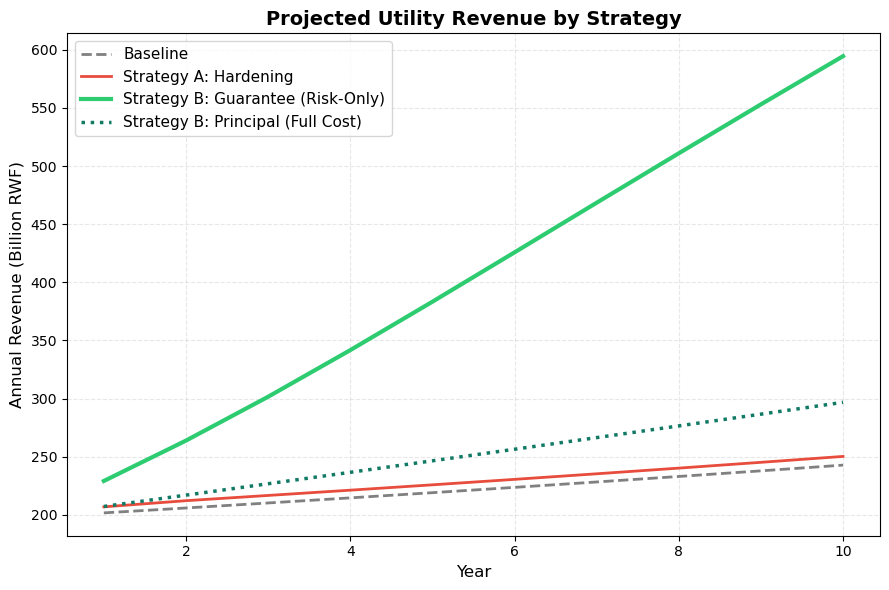

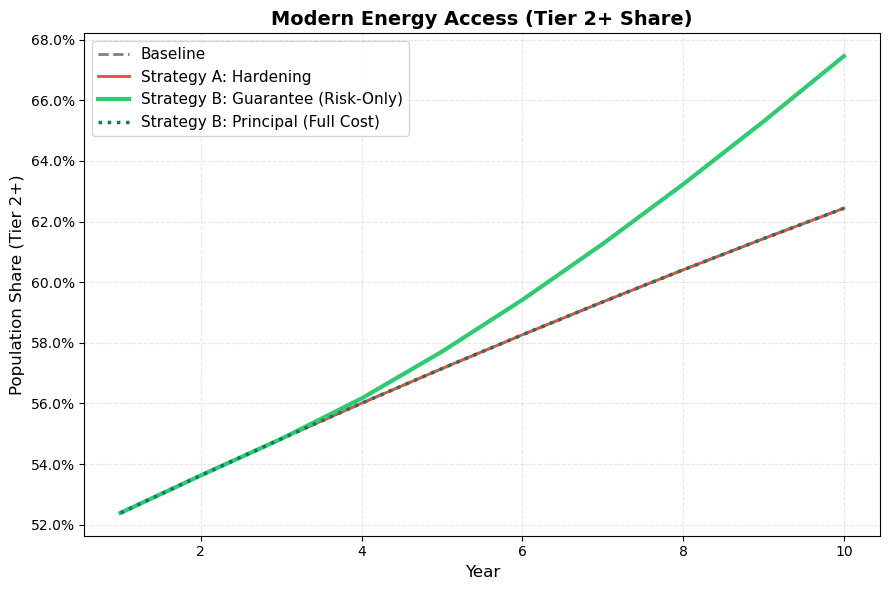

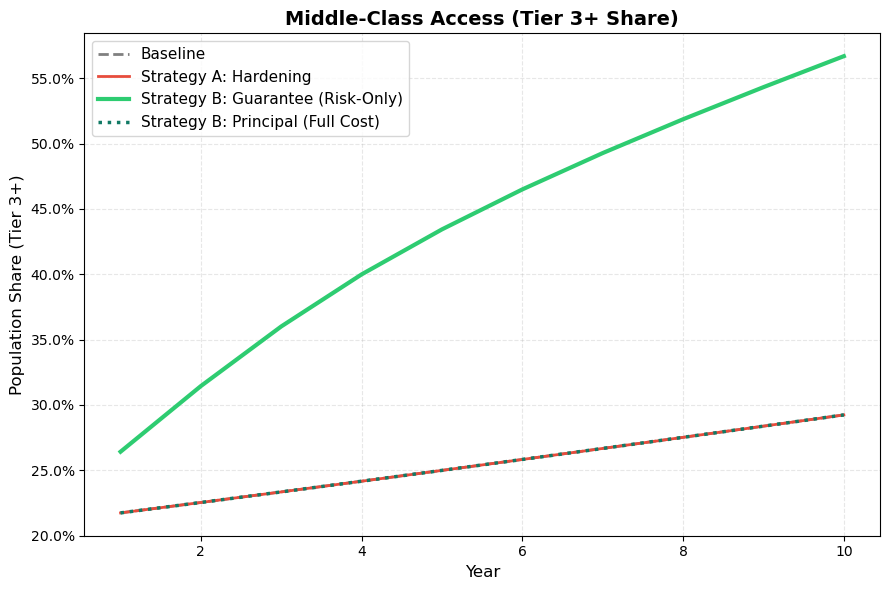


--- RESULTS SUMMARY (Year 10) ---
Revenue (Guarantee): 594.5B
Revenue (Principal): 296.8B
Tier 2+ (Guarantee): 67.5%
Tier 2+ (Principal): 62.4%
Tier 3+ (Guarantee): 56.7%
Tier 3+ (Principal): 29.2%


In [35]:
# --- Cell 14: 10-Year Projections (A vs B-Guarantee vs B-Principal) ---
import matplotlib.ticker as mtick

# === 1. CONFIGURATION ===
BUDGET_PER_YEAR = 20_000_000_000
ABS_LIFT = float(PROB_LIFT_FROM_DATA) if 'PROB_LIFT_FROM_DATA' in globals() else 0.15
BASE_DRIFT_RATE = 0.026

# Cost Constants
COST_A = CONFIG_FAIR['COST_GRID_PER_HH'] # 100,000

principal   = CONFIG_FAIR['COST_CAPITAL_SUBSIDY']
exp_loss    = principal * CONFIG_FAIR['DEFAULT_RATE']
admin_cost  = CONFIG_FAIR['ADMIN_PER_LOAN']

# Define the two costs for B
COST_B_GUARANTEE = max(exp_loss + admin_cost, 1e-9)  # ~29k
COST_B_PRINCIPAL = max(principal + admin_cost, 1e-9) # ~305k

print(f"--- COST PARAMETERS ---")
print(f"Strategy A (Hardening):   {COST_A:,.0f} RWF")
print(f"Strategy B (Guarantee):   {COST_B_GUARANTEE:,.0f} RWF (Risk Only)")
print(f"Strategy B (Principal):   {COST_B_PRINCIPAL:,.0f} RWF (Full Cost)")
print("-" * 30)

# --- 2. HELPER FUNCTIONS (Same Robust Logic) ---
def block_bill(kwh, blocks):
    bill, rem, prev = 0.0, float(kwh), 0
    for b in sorted(blocks, key=lambda z: z['limit']):
        span = b['limit'] - prev
        take = min(rem, span)
        bill += take * b['price']
        rem  -= take
        prev  = b['limit']
        if rem <= 0: break
    return bill

def current_revenue(state):
    mask = state['Conn_Grid'] == 1
    if not mask.any(): return 0.0
    base = state.loc[mask].copy()
    monthly_kwh = base['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0).astype(float)
    eff_kwh = monthly_kwh * base['m_R'].clip(0,1)
    bills = eff_kwh.apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    return float(np.sum(bills * base['HH_WT']))

def share_tier_x_plus(state, x=2):
    mask = state['Conn_Grid'] == 1
    wtot = float(state.loc[mask, 'HH_WT'].sum())
    if wtot <= 0: return 0.0
    return float(np.sum((state.loc[mask, 'Tier'] >= x).astype(float) * state.loc[mask, 'HH_WT']) / wtot)

def apply_natural_drift(state, rate=BASE_DRIFT_RATE):
    st = state.copy()
    mask = st['Conn_Grid'] == 1
    st['HH_Move'] = np.where(mask, st['HH_WT'] * rate, 0.0)
    st['HH_Stay'] = st['HH_WT'] - st['HH_Move']
    
    moved = st[mask].copy()
    moved['HH_WT'] = moved['HH_Move']
    moved['Tier'] = (moved['Tier'] + 1).clip(0, 5)
    stayed = st.copy()
    stayed['HH_WT'] = stayed['HH_Stay']
    out = pd.concat([stayed, moved], ignore_index=True)
    return out[out['HH_WT'] > 0].groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def with_roi_columns(state, cost_A, cost_B):
    st = state.copy()
    base_kwh = st['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    next_kwh = (st['Tier'] + 1).clip(0,5).map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    m0 = st['m_R'].astype(float).clip(0,1)
    
    # Bills
    bill0 = (base_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    bill1 = (next_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    
    # ROI A (Hardening)
    m1 = np.minimum(m0 * 1.2, 0.99)
    bill0_improved = (base_kwh * m1).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    st['ROI_A'] = np.where(st['Conn_Grid']==1, (bill0_improved - bill0) / max(cost_A,1e-9), 0.0)
    
    # ROI B (Financing)
    prob_adopt = ABS_LIFT * np.power(m0, 0.6)
    st['ROI_B'] = np.where((st['Conn_Grid']==1) & (st['Tier']<5), 
                           ((bill1 - bill0) * prob_adopt) / max(cost_B,1e-9), 0.0)
    return st

def apply_hardening_year(state, budget, cost_A):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, cost_A, 999999) # Cost B irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_A'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_A', ascending=False)
    treat_units = budget / cost_A
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))
            
    treated = candidates[candidates['take'] > 0].copy()
    treated['HH_WT'] = treated['take']
    treated['m_R'] = np.minimum(treated['m_R'] * 1.2, 0.99)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9] 
    
    out = pd.concat([treated, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def apply_finance_year(state, budget, cost_B):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, 999999, cost_B) # Cost A irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_B'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_B', ascending=False)
    treat_units = budget / cost_B
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))

    treated_part = candidates[candidates['take'] > 0].copy()
    treated_part['HH_WT'] = treated_part['take']
    
    p = np.clip(ABS_LIFT * np.power(treated_part['m_R'].astype(float).clip(0,1), 0.6), 0.0, 1.0)
    
    upgraders = treated_part.copy()
    upgraders['HH_WT'] = treated_part['HH_WT'] * p
    upgraders['Tier'] = (upgraders['Tier'] + 1).clip(0,5)
    non_upgraders = treated_part.copy()
    non_upgraders['HH_WT'] = treated_part['HH_WT'] * (1 - p)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9]

    out = pd.concat([upgraders, non_upgraders, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

# --- 3. RUNNING ALL SCENARIOS ---
# Initial State
state0 = df_agents.rename(columns={'UsabilityIndex':'m_R','CapacityTier':'Tier'}).copy()
for c in ['Tier','m_R','HH_WT','Conn_Grid']: state0[c] = pd.to_numeric(state0[c], errors='coerce').fillna(0)

years = range(1, 11)

# DEFINE KEYS FOR FULL LEGEND NAMES
KEY_BASE   = 'Baseline'
KEY_STRAT_A = 'Strategy A: Hardening'
KEY_GUAR   = 'Strategy B: Guarantee (Risk-Only)'
KEY_PRINC  = 'Strategy B: Principal (Full Cost)'

results = {
    KEY_BASE:   {'rev': [], 'share2': [], 'share3': []},
    KEY_STRAT_A: {'rev': [], 'share2': [], 'share3': []},
    KEY_GUAR:   {'rev': [], 'share2': [], 'share3': []},
    KEY_PRINC:  {'rev': [], 'share2': [], 'share3': []}
}

# 1. Baseline
curr = state0.copy()
for t in years:
    curr = apply_natural_drift(curr)
    results[KEY_BASE]['rev'].append(current_revenue(curr))
    results[KEY_BASE]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_BASE]['share3'].append(share_tier_x_plus(curr, 3))

# 2. Strategy A (Hardening)
curr = state0.copy()
for t in years:
    curr = apply_hardening_year(curr, BUDGET_PER_YEAR, COST_A)
    results[KEY_STRAT_A]['rev'].append(current_revenue(curr))
    results[KEY_STRAT_A]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_STRAT_A]['share3'].append(share_tier_x_plus(curr, 3))

# 3. Strategy B (Guarantee)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_GUARANTEE)
    results[KEY_GUAR]['rev'].append(current_revenue(curr))
    results[KEY_GUAR]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_GUAR]['share3'].append(share_tier_x_plus(curr, 3))

# 4. Strategy B (Principal)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_PRINCIPAL)
    results[KEY_PRINC]['rev'].append(current_revenue(curr))
    results[KEY_PRINC]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_PRINC]['share3'].append(share_tier_x_plus(curr, 3))

print("Simulations Complete.")

# --- 4. PLOTTING FIGURES ---

# STYLE SETTINGS (Mapped to Full Names)
colors = {
    KEY_BASE:   'gray',
    KEY_STRAT_A: '#e74c3c',         # Red
    KEY_GUAR:   '#2ecc71',          # Bright Green
    KEY_PRINC:  '#117A65'           # Dark Green
}
styles = {
    KEY_BASE:   '--',
    KEY_STRAT_A: '-',
    KEY_GUAR:   '-',
    KEY_PRINC:  ':'
}
widths = {
    KEY_BASE:   2,
    KEY_STRAT_A: 2,
    KEY_GUAR:   3,
    KEY_PRINC:  2.5
}

def plot_scenario(metric_key, title, ylabel, filename, percent=False):
    plt.figure(figsize=(9, 6))
    
    # Iterate in specific order for legend consistency
    for name in [KEY_BASE, KEY_STRAT_A, KEY_GUAR, KEY_PRINC]:
        y_vals = np.array(results[name][metric_key])
        if metric_key == 'rev': y_vals /= 1e9 # Billions
        
        plt.plot(years, y_vals, 
                 linestyle=styles[name], 
                 color=colors[name], 
                 linewidth=widths[name], 
                 label=name)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=11, loc='best')
    
    if percent:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# FIGURE 1: REVENUE
plot_scenario('rev', "Projected Utility Revenue by Strategy", "Annual Revenue (Billion RWF)", "revenue_impact.png")

# FIGURE 2: TIER 2+ ACCESS
plot_scenario('share2', "Modern Energy Access (Tier 2+ Share)", "Population Share (Tier 2+)", "tier2_access.png", percent=True)

# FIGURE 3: TIER 3+ ACCESS
plot_scenario('share3', "Middle-Class Access (Tier 3+ Share)", "Population Share (Tier 3+)", "tier3_access.png", percent=True)

print("\n--- RESULTS SUMMARY (Year 10) ---")
print(f"Revenue (Guarantee): {results[KEY_GUAR]['rev'][-1]/1e9:.1f}B")
print(f"Revenue (Principal): {results[KEY_PRINC]['rev'][-1]/1e9:.1f}B")
print(f"Tier 2+ (Guarantee): {results[KEY_GUAR]['share2'][-1]:.1%}")
print(f"Tier 2+ (Principal): {results[KEY_PRINC]['share2'][-1]:.1%}")
print(f"Tier 3+ (Guarantee): {results[KEY_GUAR]['share3'][-1]:.1%}")
print(f"Tier 3+ (Principal): {results[KEY_PRINC]['share3'][-1]:.1%}")

--- COST PARAMETERS (PER HOUSEHOLD) ---
Strategy A (Hardening):   100,000 RWF
Strategy B (Guarantee):   29,000 RWF (Leveraged/Risk-Only)
Strategy B (Principal):   305,000 RWF (Direct Lending/Full Cost)
Levrage Ratio (Prin/Guar): 10.5x
------------------------------
Simulations Complete.


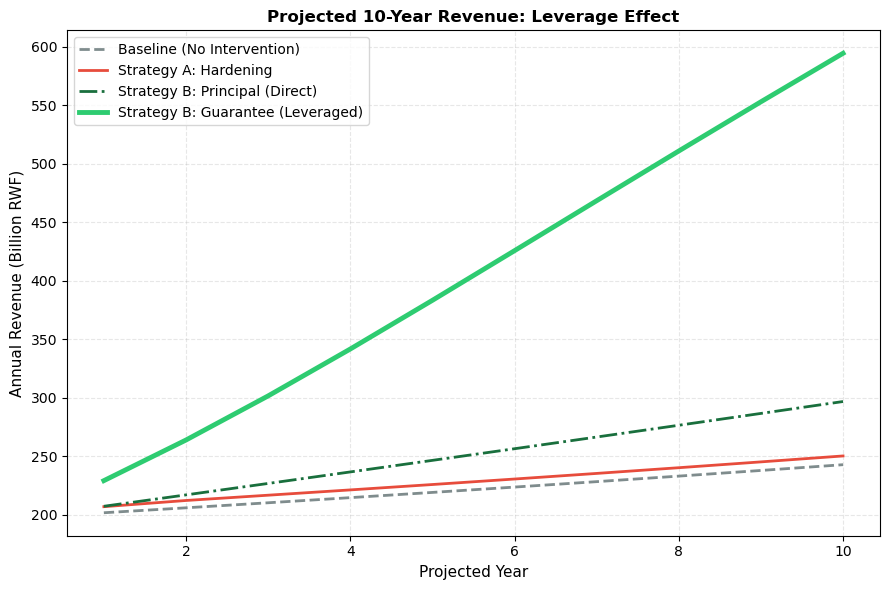

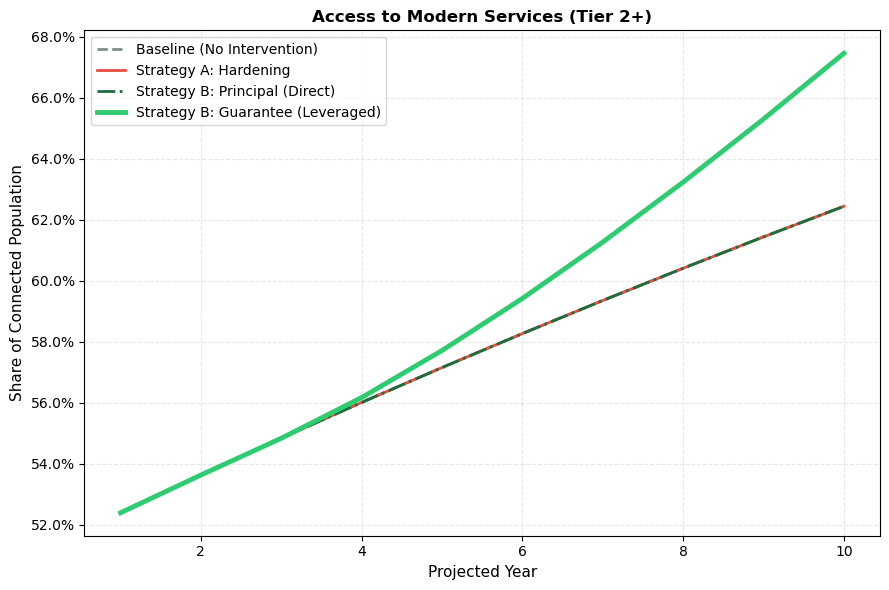

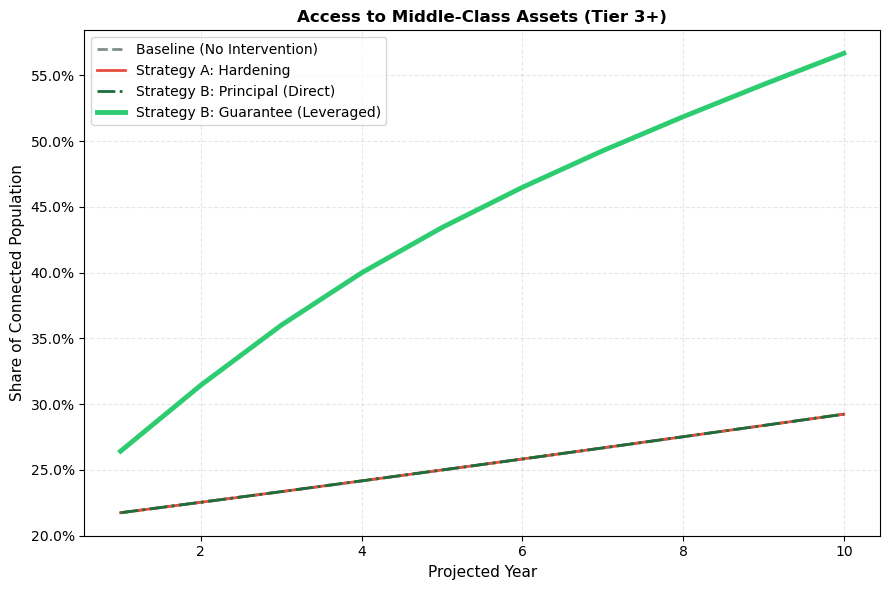


--- RESULTS SUMMARY (Year 10) ---
Revenue (Guarantee): 594.5B RWF
Revenue (Principal): 296.8B RWF
Revenue Multiplier:  2.00x
------------------------------
Tier 2+ (Guarantee): 67.5%
Tier 2+ (Principal): 62.4%
------------------------------
Tier 3+ (Guarantee): 56.7%
Tier 3+ (Principal): 29.2%


In [36]:
# Cell 14: 10-Year Projections (Leverage & Scalability Analysis)
import matplotlib.ticker as mtick

# === 1. CONFIGURATION ===
BUDGET_PER_YEAR = 20_000_000_000
ABS_LIFT = float(PROB_LIFT_FROM_DATA) if 'PROB_LIFT_FROM_DATA' in globals() else 0.15
BASE_DRIFT_RATE = 0.026

# Cost Constants
COST_A = CONFIG_FAIR['COST_GRID_PER_HH'] # 100,000

principal   = CONFIG_FAIR['COST_CAPITAL_SUBSIDY']
exp_loss    = principal * CONFIG_FAIR['DEFAULT_RATE']
admin_cost  = CONFIG_FAIR['ADMIN_PER_LOAN']

# Define the two costs for B
COST_B_GUARANTEE = max(exp_loss + admin_cost, 1e-9)  # ~29k (Risk + Admin)
COST_B_PRINCIPAL = max(principal + admin_cost, 1e-9) # ~305k (Full Capital + Admin)

print(f"--- COST PARAMETERS (PER HOUSEHOLD) ---")
print(f"Strategy A (Hardening):   {COST_A:,.0f} RWF")
print(f"Strategy B (Guarantee):   {COST_B_GUARANTEE:,.0f} RWF (Leveraged/Risk-Only)")
print(f"Strategy B (Principal):   {COST_B_PRINCIPAL:,.0f} RWF (Direct Lending/Full Cost)")
print(f"Levrage Ratio (Prin/Guar): {COST_B_PRINCIPAL/COST_B_GUARANTEE:.1f}x")
print("-" * 30)

# --- 2. HELPER FUNCTIONS ---
# (Logic remains identical to preserve simulation integrity)
def block_bill(kwh, blocks):
    bill, rem, prev = 0.0, float(kwh), 0
    for b in sorted(blocks, key=lambda z: z['limit']):
        span = b['limit'] - prev
        take = min(rem, span)
        bill += take * b['price']
        rem  -= take
        prev  = b['limit']
        if rem <= 0: break
    return bill

def current_revenue(state):
    mask = state['Conn_Grid'] == 1
    if not mask.any(): return 0.0
    base = state.loc[mask].copy()
    monthly_kwh = base['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0).astype(float)
    eff_kwh = monthly_kwh * base['m_R'].clip(0,1)
    bills = eff_kwh.apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    return float(np.sum(bills * base['HH_WT']))

def share_tier_x_plus(state, x=2):
    mask = state['Conn_Grid'] == 1
    wtot = float(state.loc[mask, 'HH_WT'].sum())
    if wtot <= 0: return 0.0
    return float(np.sum((state.loc[mask, 'Tier'] >= x).astype(float) * state.loc[mask, 'HH_WT']) / wtot)

def apply_natural_drift(state, rate=BASE_DRIFT_RATE):
    st = state.copy()
    mask = st['Conn_Grid'] == 1
    st['HH_Move'] = np.where(mask, st['HH_WT'] * rate, 0.0)
    st['HH_Stay'] = st['HH_WT'] - st['HH_Move']
    
    moved = st[mask].copy()
    moved['HH_WT'] = moved['HH_Move']
    moved['Tier'] = (moved['Tier'] + 1).clip(0, 5)
    stayed = st.copy()
    stayed['HH_WT'] = stayed['HH_Stay']
    out = pd.concat([stayed, moved], ignore_index=True)
    return out[out['HH_WT'] > 0].groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def with_roi_columns(state, cost_A, cost_B):
    st = state.copy()
    base_kwh = st['Tier'].map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    next_kwh = (st['Tier'] + 1).clip(0,5).map(CONFIG_FAIR['TIER_KWH_MONTHLY']).fillna(0)
    m0 = st['m_R'].astype(float).clip(0,1)
    
    # Bills
    bill0 = (base_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    bill1 = (next_kwh * m0).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    
    # ROI A (Hardening)
    m1 = np.minimum(m0 * 1.2, 0.99)
    bill0_improved = (base_kwh * m1).apply(lambda k: block_bill(k, CONFIG_FAIR['TARIFF_BLOCKS'])) * 12
    st['ROI_A'] = np.where(st['Conn_Grid']==1, (bill0_improved - bill0) / max(cost_A,1e-9), 0.0)
    
    # ROI B (Financing)
    prob_adopt = ABS_LIFT * np.power(m0, 0.6)
    st['ROI_B'] = np.where((st['Conn_Grid']==1) & (st['Tier']<5), 
                           ((bill1 - bill0) * prob_adopt) / max(cost_B,1e-9), 0.0)
    return st

def apply_hardening_year(state, budget, cost_A):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, cost_A, 999999) # Cost B irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_A'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_A', ascending=False)
    treat_units = budget / cost_A
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))
            
    treated = candidates[candidates['take'] > 0].copy()
    treated['HH_WT'] = treated['take']
    treated['m_R'] = np.minimum(treated['m_R'] * 1.2, 0.99)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9] 
    
    out = pd.concat([treated, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

def apply_finance_year(state, budget, cost_B):
    state = apply_natural_drift(state)
    st = with_roi_columns(state, 999999, cost_B) # Cost A irrelevant here
    
    mask_eligible = (st['Conn_Grid']==1) & (st['ROI_B'] > 0)
    candidates = st[mask_eligible].copy()
    others = st[~mask_eligible].copy()
    
    if candidates.empty: return state

    candidates = candidates.sort_values('ROI_B', ascending=False)
    treat_units = budget / cost_B
    candidates['cumsum_wt'] = candidates['HH_WT'].cumsum()
    candidates['take'] = np.minimum(candidates['HH_WT'], np.maximum(0, treat_units - (candidates['cumsum_wt'] - candidates['HH_WT'])))

    treated_part = candidates[candidates['take'] > 0].copy()
    treated_part['HH_WT'] = treated_part['take']
    
    p = np.clip(ABS_LIFT * np.power(treated_part['m_R'].astype(float).clip(0,1), 0.6), 0.0, 1.0)
    
    upgraders = treated_part.copy()
    upgraders['HH_WT'] = treated_part['HH_WT'] * p
    upgraders['Tier'] = (upgraders['Tier'] + 1).clip(0,5)
    non_upgraders = treated_part.copy()
    non_upgraders['HH_WT'] = treated_part['HH_WT'] * (1 - p)
    
    candidates['HH_WT'] = np.maximum(candidates['HH_WT'] - candidates['take'], 0.0)
    untreated = candidates[candidates['HH_WT'] > 1e-9]

    out = pd.concat([upgraders, non_upgraders, untreated, others], ignore_index=True)
    return out.groupby(['hhid','Conn_Grid','Tier','m_R'], as_index=False)['HH_WT'].sum()

# --- 3. RUNNING ALL SCENARIOS ---
state0 = df_agents.rename(columns={'UsabilityIndex':'m_R','CapacityTier':'Tier'}).copy()
for c in ['Tier','m_R','HH_WT','Conn_Grid']: state0[c] = pd.to_numeric(state0[c], errors='coerce').fillna(0)

years = range(1, 11)

# Names for Legend
KEY_BASE    = 'Baseline (No Intervention)'
KEY_STRAT_A = 'Strategy A: Hardening'
KEY_GUAR    = 'Strategy B: Guarantee (Leveraged)'
KEY_PRINC   = 'Strategy B: Principal (Direct)'

results = {
    KEY_BASE:    {'rev': [], 'share2': [], 'share3': []},
    KEY_STRAT_A: {'rev': [], 'share2': [], 'share3': []},
    KEY_GUAR:    {'rev': [], 'share2': [], 'share3': []},
    KEY_PRINC:   {'rev': [], 'share2': [], 'share3': []}
}

# 1. Baseline
curr = state0.copy()
for t in years:
    curr = apply_natural_drift(curr)
    results[KEY_BASE]['rev'].append(current_revenue(curr))
    results[KEY_BASE]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_BASE]['share3'].append(share_tier_x_plus(curr, 3))

# 2. Strategy A
curr = state0.copy()
for t in years:
    curr = apply_hardening_year(curr, BUDGET_PER_YEAR, COST_A)
    results[KEY_STRAT_A]['rev'].append(current_revenue(curr))
    results[KEY_STRAT_A]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_STRAT_A]['share3'].append(share_tier_x_plus(curr, 3))

# 3. Strategy B (Guarantee)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_GUARANTEE)
    results[KEY_GUAR]['rev'].append(current_revenue(curr))
    results[KEY_GUAR]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_GUAR]['share3'].append(share_tier_x_plus(curr, 3))

# 4. Strategy B (Principal)
curr = state0.copy()
for t in years:
    curr = apply_finance_year(curr, BUDGET_PER_YEAR, COST_B_PRINCIPAL)
    results[KEY_PRINC]['rev'].append(current_revenue(curr))
    results[KEY_PRINC]['share2'].append(share_tier_x_plus(curr, 2))
    results[KEY_PRINC]['share3'].append(share_tier_x_plus(curr, 3))

print("Simulations Complete.")

# --- 4. PLOTTING ---

# Styles
colors = {
    KEY_BASE:    '#7f8c8d',     # Gray
    KEY_STRAT_A: '#e74c3c',     # Red
    KEY_GUAR:    '#2ecc71',     # Bright Green (Optimal)
    KEY_PRINC:   '#196f3d'      # Dark Green (Sub-optimal)
}
styles = {
    KEY_BASE:    '--',
    KEY_STRAT_A: '-',
    KEY_GUAR:    '-',
    KEY_PRINC:   '-.'
}
widths = {
    KEY_BASE:    2,
    KEY_STRAT_A: 2,
    KEY_GUAR:    3.5,           # Emphasize the winner
    KEY_PRINC:   2
}

def plot_scenario(metric_key, title, ylabel, filename, percent=False):
    plt.figure(figsize=(9, 6))
    
    # Order: Base, A, Principal, Guarantee (so Guarantee is on top)
    plot_order = [KEY_BASE, KEY_STRAT_A, KEY_PRINC, KEY_GUAR]
    
    for name in plot_order:
        y_vals = np.array(results[name][metric_key])
        if metric_key == 'rev': y_vals /= 1e9 # Billions
        
        plt.plot(years, y_vals, 
                 linestyle=styles[name], 
                 color=colors[name], 
                 linewidth=widths[name], 
                 label=name)

    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Projected Year", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=10, loc='best', frameon=True)
    
    if percent:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Generate Plots
plot_scenario('rev', "Projected 10-Year Revenue: Leverage Effect", "Annual Revenue (Billion RWF)", "fig_proj_revenue.png")
plot_scenario('share2', "Access to Modern Services (Tier 2+)", "Share of Connected Population", "fig_proj_tier2.png", percent=True)
plot_scenario('share3', "Access to Middle-Class Assets (Tier 3+)", "Share of Connected Population", "fig_proj_tier3.png", percent=True)

# --- 5. FINAL RESULTS SUMMARY ---
print("\n--- RESULTS SUMMARY (Year 10) ---")
print(f"Revenue (Guarantee): {results[KEY_GUAR]['rev'][-1]/1e9:.1f}B RWF")
print(f"Revenue (Principal): {results[KEY_PRINC]['rev'][-1]/1e9:.1f}B RWF")
print(f"Revenue Multiplier:  {results[KEY_GUAR]['rev'][-1] / results[KEY_PRINC]['rev'][-1]:.2f}x")
print("-" * 30)
print(f"Tier 2+ (Guarantee): {results[KEY_GUAR]['share2'][-1]:.1%}")
print(f"Tier 2+ (Principal): {results[KEY_PRINC]['share2'][-1]:.1%}")
print("-" * 30)
print(f"Tier 3+ (Guarantee): {results[KEY_GUAR]['share3'][-1]:.1%}")
print(f"Tier 3+ (Principal): {results[KEY_PRINC]['share3'][-1]:.1%}")

In [37]:
# === Print Agent Stats table values (no LaTeX macros, no file write) ===
import numpy as np
import pandas as pd
import os

def _wavg(series, weights):
    s = pd.to_numeric(series, errors='coerce')
    w = pd.to_numeric(weights, errors='coerce')
    m = s.notna() & np.isfinite(s) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(s[m], weights=w[m]))

def _fmt_pct_plain(x, digits=1):
    if x is None or not np.isfinite(x):
        return "--"
    return f"{x*100:.{digits}f}%"

def _fmt_num_plain(x, digits=2):
    if x is None or not np.isfinite(x):
        return "--"
    return f"{x:.{digits}f}"

def _fmt_int_plain(x):
    try:
        v = int(round(float(x)))
        return f"{v:,d}"
    except Exception:
        return "--"

# ---------- Gather sources ----------
if 'df' not in globals():
    raise RuntimeError("Expected dataframe 'df' from earlier cells.")
if 'df_agents' not in globals():
    raise RuntimeError("Expected dataframe 'df_agents' from earlier cells.")

# Base (full) survey for urban/rural & weights
base = df[['hhid','HH_WT','Is_Urban']].copy() if 'Is_Urban' in df.columns else df[['hhid','HH_WT']].copy()
if 'Is_Urban' not in base.columns:
    base['Is_Urban'] = np.nan

# Agents view for connection, reliability, tiers, Section-H answers
ag = df_agents.copy()

# Normalize aliases
if 'm_R' not in ag.columns and 'UsabilityIndex' in ag.columns:
    ag['m_R'] = pd.to_numeric(ag['UsabilityIndex'], errors='coerce')
if 'Tier' not in ag.columns and 'CapacityTier' in ag.columns:
    ag['Tier'] = pd.to_numeric(ag['CapacityTier'], errors='coerce').astype('Int64')

# Merge Urban/Rural via hhid (safe even if missing)
ag = ag.merge(base[['hhid','Is_Urban','HH_WT']], on='hhid', how='left', suffixes=('','_base'))

# Prefer agent HH_WT if present; else take base
if 'HH_WT_x' in ag.columns and 'HH_WT_y' in ag.columns:
    ag['HH_WT'] = ag['HH_WT_x'].fillna(ag['HH_WT_y'])
    ag.drop(columns=['HH_WT_x','HH_WT_y'], inplace=True)

# Coerce key columns
for c in ['Conn_Grid','m_R','Tier','HH_WT','Is_Urban']:
    if c in ag.columns:
        ag[c] = pd.to_numeric(ag[c], errors='coerce')

ag['Conn_Grid'] = (ag.get('Conn_Grid', 0) == 1).astype(int)
ag['Is_Urban'] = (ag.get('Is_Urban', 0) == 1).astype(int)
ag['HH_WT'] = ag['HH_WT'].fillna(0)

# Section H (if present in agents) OR from df_h_raw
if all(c in ag.columns for c in ['H03','H04','H05','H06']):
    H_local = ag[['hhid','H03','H04','H05','H06']].copy()
    H_local['H_WT'] = ag['HH_WT'].values
else:
    H_local = None

if H_local is None and 'df_h_raw' in globals() and df_h_raw is not None:
    H_local = df_h_raw[['hhid','H03','H04','H05','H06','HH_WT']].copy()
    H_local = H_local.rename(columns={'HH_WT':'H_WT'})

# ---------- Compute metrics ----------
Nraw_val = len(df)  # unweighted households in analytic file
connected = ag[ag['Conn_Grid'] == 1].copy()

Nconn_val = len(connected)
Popwt_val = connected['HH_WT'].sum()

mR_mean_val  = _wavg(connected['m_R'], connected['HH_WT'])
mR_urban_val = _wavg(connected.loc[connected['Is_Urban']==1, 'm_R'],
                     connected.loc[connected['Is_Urban']==1, 'HH_WT'])
mR_rural_val = _wavg(connected.loc[connected['Is_Urban']==0, 'm_R'],
                     connected.loc[connected['Is_Urban']==0, 'HH_WT'])

def tier_share(t):
    if Popwt_val <= 0:
        return np.nan
    w = connected.loc[connected['Tier'] == t, 'HH_WT'].sum()
    return w / Popwt_val

pT1 = tier_share(1); pT2 = tier_share(2); pT3 = tier_share(3); pT4 = tier_share(4); pT5 = tier_share(5)
pTge2 = sum(x for x in [pT2, pT3, pT4, pT5] if x is not None and np.isfinite(x))

# Credit metrics (use Section-H weights if available)
pCash = np.nan; pCreditAny = np.nan; liftAbs = np.nan
if H_local is not None and not H_local.empty:
    H = H_local.copy()
    for c in ['H03','H04','H05','H06','H_WT']:
        H[c] = pd.to_numeric(H[c], errors='coerce')
    H = H[np.isfinite(H['H_WT']) & (H['H_WT'] > 0)]
    H['Accept_Cash']       = (H['H03'] == 1).astype(int)
    H['Accept_Credit_Any'] = ((H['H03']==1)|(H['H04']==1)|(H['H05']==1)|(H['H06']==1)).astype(int)

    pCash      = _wavg(H['Accept_Cash'], H['H_WT'])
    pCreditAny = _wavg(H['Accept_Credit_Any'], H['H_WT'])
    liftAbs    = (pCreditAny - pCash) if (np.isfinite(pCash) and np.isfinite(pCreditAny)) else np.nan

# ---------- Print results ----------
print("\n=== Agent Stats (printed values) ===")
print(f"Nraw (unweighted households in df): { _fmt_int_plain(Nraw_val) }")
print(f"Nconn (connected households):       { _fmt_int_plain(Nconn_val) }")
print(f"Popwt (weighted connected pop):     { _fmt_int_plain(Popwt_val) }")
print("")
print(f"m_R mean (weighted):                { _fmt_num_plain(mR_mean_val, 2) }")
print(f"m_R urban (weighted):               { _fmt_num_plain(mR_urban_val, 2) }")
print(f"m_R rural (weighted):               { _fmt_num_plain(mR_rural_val, 2) }")
print("")
print("Tier shares among connected (weighted):")
print(f"  Tier 1:                           { _fmt_pct_plain(pT1, 1) }")
print(f"  Tier 2:                           { _fmt_pct_plain(pT2, 1) }")
print(f"  Tier 3:                           { _fmt_pct_plain(pT3, 1) }")
print(f"  Tier 4:                           { _fmt_pct_plain(pT4, 1) }")
print(f"  Tier 5:                           { _fmt_pct_plain(pT5, 1) }")
print(f"  Tier >=2:                         { _fmt_pct_plain(pTge2, 1) }")
print("")
print("Payment acceptance (weighted; Section H if available):")
print(f"  Accept cash:                      { _fmt_pct_plain(pCash, 1) }")
print(f"  Accept any credit:                { _fmt_pct_plain(pCreditAny, 1) }")
print(f"  Lift (credit - cash), abs pts:    { _fmt_pct_plain(liftAbs, 1) }")



=== Agent Stats (printed values) ===
Nraw (unweighted households in df): 5,706
Nconn (connected households):       2,661
Popwt (weighted connected pop):     1,520,388

m_R mean (weighted):                0.97
m_R urban (weighted):               0.98
m_R rural (weighted):               0.96

Tier shares among connected (weighted):
  Tier 1:                           48.9%
  Tier 2:                           30.2%
  Tier 3:                           0.7%
  Tier 4:                           18.7%
  Tier 5:                           1.6%
  Tier >=2:                         51.1%

Payment acceptance (weighted; Section H if available):
  Accept cash:                      30.6%
  Accept any credit:                48.9%
  Lift (credit - cash), abs pts:    18.3%


--- STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: 74.2%) ---
Cost Structure Risk: 66.1%
Behavioral Risk: 74.2%
Technical Risk: 74.2%
Credit Risk: 73.0%
Adoption Risk: 59.9%


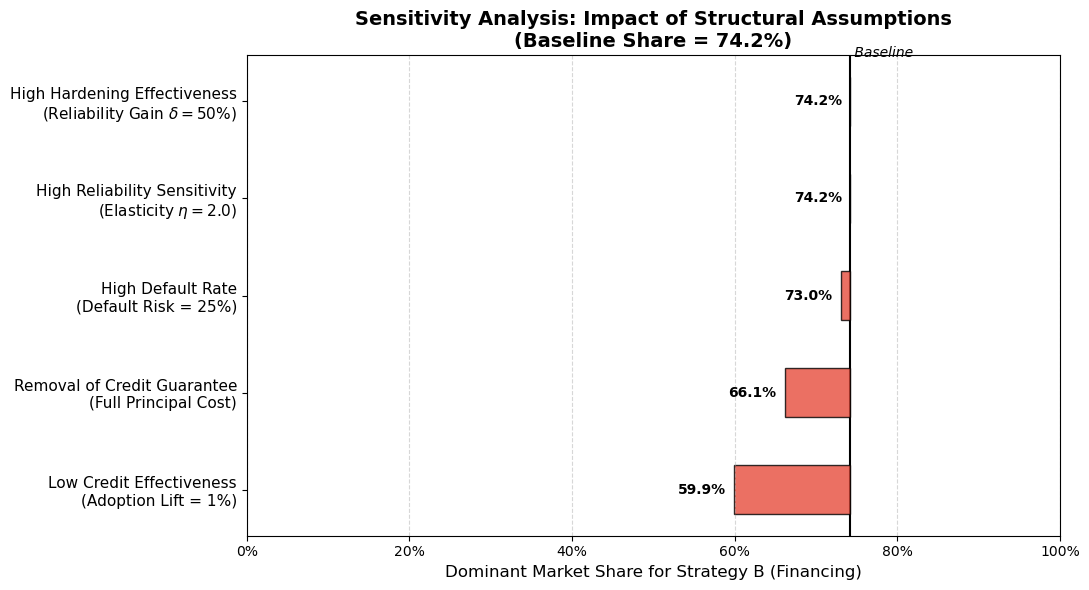

In [38]:
# Cell 15: Sensitivity Analysis - Tornado Diagram
# 1. Update the Solver to be Dynamic
def calculate_stackelberg_dynamic(agent_df, config, absolute_lift=0.15, 
                                  eta=0.6, delta=0.2):
    df = agent_df.copy()

    # Aliases
    if 'Tier' not in df.columns: df['Tier'] = df['CapacityTier'].astype(int)
    if 'm_R' not in df.columns:  df['m_R']  = df['UsabilityIndex'].astype(float)
    df['Accept_Cash'] = (pd.to_numeric(df['H03'], errors='coerce') == 1).astype(int)

    # 1. BASELINE REVENUE
    base_kwh = df['Tier'].map(config['TIER_KWH_MONTHLY']).fillna(0)
    u0 = df['m_R'].replace(0, 0.01)
    
    # 2. STRATEGY A (Hardening) - Dynamic Delta
    u1 = np.minimum(u0 * (1 + delta), 0.99)
    base_rev = (base_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    strat_A_rev = (base_kwh * u1).apply(lambda k: annual_bill_from_kwh(k, config))
    
    gain_A = strat_A_rev - base_rev
    cost_A = config['COST_GRID_PER_HH']
    df['ROI_A'] = np.where(df['Conn_Grid'] == 1, gain_A / cost_A, 0.0)

    # 3. STRATEGY B (Financing) - Dynamic Eta
    next_kwh = (df['Tier'] + 1).clip(0, 5).map(config['TIER_KWH_MONTHLY'])
    next_rev = (next_kwh * u0).apply(lambda k: annual_bill_from_kwh(k, config))
    
    # Dynamic Risk Aversion
    prob_adopt = absolute_lift * np.power(u0, eta)
    rev_gain_B = (next_rev - base_rev) * prob_adopt
    
    # Cost
    risk_cost = config['COST_CAPITAL_SUBSIDY'] * config['DEFAULT_RATE']
    cost_B = max(risk_cost + config['ADMIN_PER_LOAN'], 1e-9)
    
    elig_B = (df['Tier'] < 5) & ((df['Accept_Cash'] == 0) | (df['H04'] == 1) | (df['H05'] == 1) | (df['H06'] == 1))
    rev_gain_B[~elig_B] = 0.0
    
    df['ROI_B'] = np.where(df['Conn_Grid'] == 1, rev_gain_B / cost_B, 0.0)

    # 4. Winner
    EPS = 1e-9
    df['Winner'] = 'None'
    mask_A = (df['ROI_A'] > df['ROI_B'] + EPS) & (df['ROI_A'] > EPS)
    mask_B = (df['ROI_B'] > df['ROI_A'] + EPS) & (df['ROI_B'] > EPS)
    df.loc[mask_A, 'Winner'] = 'Hardening'
    df.loc[mask_B, 'Winner'] = 'Financing'
    
    return df

# 2. Define Sensitivity Scenarios
stress_scenarios = [
    ("Removal of Credit Guarantee\n(Full Principal Cost)", "PRINCIPAL_MODE", True, "Cost Structure Risk"),
    ("High Reliability Sensitivity\n(Elasticity $\eta = 2.0$)", "ETA", 2.0, "Behavioral Risk"),
    ("High Hardening Effectiveness\n(Reliability Gain $\delta = 50\%$)", "DELTA", 0.5, "Technical Risk"),
    ("High Default Rate\n(Default Risk = 25%)", "DEFAULT", 0.25, "Credit Risk"),
    ("Low Credit Effectiveness\n(Adoption Lift = 1%)", "LIFT", 0.01, "Adoption Risk")
]

# 3. Run and Aggregate
base_df = calculate_stackelberg_dynamic(df_agents, CONFIG_FAIR, absolute_lift=ABSOLUTE_LIFT, eta=0.6, delta=0.2)
base_conn = base_df[base_df['Conn_Grid']==1]
base_share = np.average((base_conn['Winner']=='Financing').astype(float), weights=base_conn['HH_WT'])

results = []
print(f"--- STRUCTURAL SENSITIVITY ANALYSIS (Baseline Share: {base_share:.1%}) ---")

for label, param, val, desc in stress_scenarios:
    # Reset Defaults
    cfg = CONFIG_FAIR.copy()
    lift = ABSOLUTE_LIFT
    eta = 0.6
    delta = 0.2
    
    # Apply Stress
    if param == "PRINCIPAL_MODE":
        full_cost = cfg['COST_CAPITAL_SUBSIDY'] + cfg['ADMIN_PER_LOAN']
        cfg['ADMIN_PER_LOAN'] = full_cost - (cfg['COST_CAPITAL_SUBSIDY'] * cfg['DEFAULT_RATE'])
    elif param == "ETA": eta = val
    elif param == "DELTA": delta = val
    elif param == "DEFAULT": cfg['DEFAULT_RATE'] = val
    elif param == "LIFT": lift = val
        
    # Solve
    res_df = calculate_stackelberg_dynamic(df_agents, cfg, absolute_lift=lift, eta=eta, delta=delta)
    
    # Calc Share
    conn = res_df[res_df['Conn_Grid']==1]
    share = np.average((conn['Winner']=='Financing').astype(float), weights=conn['HH_WT']) if len(conn) > 0 else 0.0
        
    delta_share = share - base_share
    results.append({'Label': label, 'Share': share, 'Delta': delta_share, 'Desc': desc})
    print(f"{desc}: {share:.1%}")

# 4. Plot Tornado
res_df = pd.DataFrame(results).sort_values('Delta', ascending=True)

plt.figure(figsize=(11, 6))
plt.axvline(base_share, color='black', linestyle='-', linewidth=1.5, zorder=0)

y_pos = np.arange(len(res_df))
for i, row in enumerate(res_df.itertuples()):
    color = '#e74c3c' if row.Delta < 0 else '#2ecc71'
    plt.barh(i, row.Delta, left=base_share, height=0.5, color=color, edgecolor='black', alpha=0.8)
    
    txt = f"{row.Share:.1%}"
    ha = 'right' if row.Delta < 0 else 'left'
    offset = -0.01 if row.Delta < 0 else 0.01
    plt.text(base_share + row.Delta + offset, i, txt, va='center', ha=ha, fontweight='bold', fontsize=10)

plt.yticks(y_pos, res_df['Label'], fontsize=11)
plt.xlabel("Dominant Market Share for Strategy B (Financing)", fontsize=12)
plt.title(f"Sensitivity Analysis: Impact of Structural Assumptions\n(Baseline Share = {base_share:.1%})", fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.text(base_share, len(res_df)-0.5, " Baseline", va='center', ha='left', fontsize=10, style='italic', color='black')

plt.tight_layout()
plt.savefig("fig_robustness_tornado.png", dpi=300)
plt.show()